# Table of Contents

1. [Introduction](#1-introduction)

2. [Initial Data Understanding](#2-initial-data-understanding)

3. [Data Loading and Initial Exploration](#3-data-loading-and-initial-exploration)
   - [3.1 Importing Libraries](#31-importing-libraries)
   - [3.2 Import Data](#32-import-data)
   - [3.3 Initial Data Inspection](#33-initial-data-inspection)
   - [3.4 Data Quality Check](#34-data-quality-check)
   - [3.5 Conclusions](#35-conclusions)

4. [Exploratory Data Analysis (EDA)](#4-exploratory-data-analysis-eda)
   - [4.1 EDA Overview](#41-eda-overview)
   - [4.2 PassengerId](#42-passengerid)
   - [4.3 Survived (Target)](#43-survived-target)
   - [4.4 Passenger Class (Pclass)](#44-passenger-class-pclass)
   - [4.5 Pclass vs Survived](#45-pclass-vs-survived)
   - [4.6 Passenger Name and Title Analysis (Name)](#46-passenger-name-and-title-analysis-name)
   - [4.7 Passenger Gender (Sex)](#47-passenger-gender-sex)
   - [4.8 Sex vs Survival](#48-sex-vs-survival)
   - [4.9 Pclass and Sex vs Survival](#49-pclass-and-sex-vs-survival)
   - [4.10 Passenger Age (Age)](#410-passenger-age-age)
   - [4.11 Age vs Survived](#411-age-vs-survived)
   - [4.12 Sex, Pclass and Age vs Survival](#412-sex-pclass-and-age-vs-survival)
   - [4.13 Family Members Aboard: SibSp and Parch](#413-family-members-aboard-sibsp-and-parch)
   - [4.14 Family Size vs Survival](#414-family-size-vs-survival)
   - [4.15 Ticket](#415-ticket)
   - [4.16 Fare](#416-fare)
   - [4.17 Fare vs Survived](#417-fare-vs-survived)
   - [4.18 Cabin](#418-cabin)
   - [4.19 Embarked](#419-embarked)
   - [4.20 Correlation Matrix](#420-correlation-matrix)

5. [Feature Engineering and Data Preprocessing](#5-feature-engineering-and-data-preprocessing)
   - [5.1 Overview](#51-overview)
   - [5.2 Handling Missing Values](#52-handling-missing-values)
   - [5.3 Feature Engineering and Feature Selection](#53-feature-engineering-and-feature-selection)

6. [Model Training and Evaluation](#6-model-training-and-evaluation)
   - [6.1 Introduction](#61-introduction)
   - [6.2 Logistic Regression Model Training](#62-logistic-regression-model-training)

7. [Final Conclusion](#7-final-conclusion)

## 1 Introduction 

**Welcome to the Kaggle community!**

This is my first public research project dedicated to data exploration and feature engineering for a machine learning model. In addition to solving the given task, I decided to present this notebook as a small guide for beginners in data analysis in order to systematize my own knowledge and share my learning process.

As my mathematical analysis professor used to say:

*"The deepest understanding of a topic is achieved through teaching others."*

That is why I decided not only to train a model but also to provide a detailed overview of the main stages of solving the problem: data preparation, feature analysis, model training, and evaluation of the obtained results.

If my notebook was useful to you or if you have any comments and suggestions for improvement, I would appreciate your feedback in the comments section. This will help me continue developing and improve the quality of my future research.

**Thank you all in advance!**

---

**Disclaimer**

* This is my first experience writing technical material in English. Since I do not yet have enough experience writing professional articles, part of the text was prepared with the help of artificial intelligence-based tools and additionally edited by me.
* While preparing this notebook, I studied other Kaggle participants' solutions and used them as a source of inspiration for the structure and presentation. Links to useful materials are provided at the end of the introduction.
* At the time of creating this notebook, my practical experience with classification tasks was limited to logistic regression. Therefore, this research will focus specifically on this algorithm: its idea, the training process, and its application for solving the given task.
* It is assumed that the reader has basic knowledge of machine learning. The purpose of this notebook is not to provide a complete theoretical explanation of every algorithm or term. The main focus is on the practical process of solving a real data analysis problem. If some concepts are unfamiliar to you, do not be discouraged: it is an excellent opportunity to spend time learning a new topic.

## 2 Initial Data Understanding

Before starting the research, it is useful to develop an initial understanding of the dataset. Since the "Titanic" dataset contains a relatively small number of features, we can manually examine each of them and formulate preliminary hypotheses about their impact on the target variable. Try to create a similar table yourself and compare it with my version.

<table style="margin-left: 0; margin-right: auto; text-align: left; border-collapse: collapse; width: 100%;">
  <thead>
    <tr style="border-bottom: 2px solid #555;">
      <th style="text-align: left; padding: 8px;">Feature</th>
      <th style="text-align: left; padding: 8px;">Data Type</th>
      <th style="text-align: left; padding: 8px;">Expected Impact</th>
      <th style="text-align: left; padding: 8px;">Validation Result</th>
      <th style="text-align: left; padding: 8px;">Description</th>
    </tr>
  </thead>
  <tbody>
    <tr style="border-bottom: 1px solid #333;">
      <td style="padding: 8px;"><b>PassengerId</b></td>
      <td style="padding: 8px;">Numerical</td>
      <td style="padding: 8px;"><b>N/A</b></td>
      <td style="padding: 8px;"><b>TBD</b></td>
      <td style="padding: 8px;">Unique ID assigned to each passenger</td>
    </tr>
    <tr style="border-bottom: 1px solid #333;">
      <td style="padding: 8px;"><b>Survived</b></td>
      <td style="padding: 8px;">Binary</td>
      <td style="padding: 8px;"><b>Target</b></td>
      <td style="padding: 8px;"><b>TBD</b></td>
      <td style="padding: 8px;">Target variable (0 = No, 1 = Yes)</td>
    </tr>
    <tr style="border-bottom: 1px solid #333;">
      <td style="padding: 8px;"><b>Pclass</b></td>
      <td style="padding: 8px;">Categorical</td>
      <td style="padding: 8px;"><b>High</b></td>
      <td style="padding: 8px;"><b>TBD</b></td>
      <td style="padding: 8px;">Ticket class (1st, 2nd, 3rd)</td>
    </tr>
    <tr style="border-bottom: 1px solid #333;">
      <td style="padding: 8px;"><b>Name</b></td>
      <td style="padding: 8px;">String</td>
      <td style="padding: 8px;"><b>Medium</b></td>
      <td style="padding: 8px;"><b>TBD</b></td>
      <td style="padding: 8px;">Passenger’s full name</td>
    </tr>
    <tr style="border-bottom: 1px solid #333;">
      <td style="padding: 8px;"><b>Sex</b></td>
      <td style="padding: 8px;">Categorical</td>
      <td style="padding: 8px;""><b>High</b></td>
      <td style="padding: 8px;"><b>TBD</b></td>
      <td style="padding: 8px;">Passenger’s gender</td>
    </tr>
    <tr style="border-bottom: 1px solid #333;">
      <td style="padding: 8px;"><b>Age</b></td>
      <td style="padding: 8px;">Numerical</td>
      <td style="padding: 8px;"><b>Medium</b></td>
      <td style="padding: 8px;"><b>TBD</b></td>
      <td style="padding: 8px;">Passenger's age</td>
    </tr>
    <tr style="border-bottom: 1px solid #333;">
      <td style="padding: 8px;"><b>SibSp</b></td>
      <td style="padding: 8px;">Numerical</td>
      <td style="padding: 8px;"><b>Low / Medium</b></td>
      <td style="padding: 8px;"><b>TBD</b></td>
      <td style="padding: 8px;">Number of siblings/spouses aboard</td>
    </tr>
    <tr style="border-bottom: 1px solid #333;">
      <td style="padding: 8px;"><b>Parch</b></td>
      <td style="padding: 8px;">Numerical</td>
      <td style="padding: 8px;"><b>Low / Medium</b></td>
      <td style="padding: 8px;"><b>TBD</b></td>
      <td style="padding: 8px;">Number of parents/children aboard</td>
    </tr>
    <tr style="border-bottom: 1px solid #333;">
      <td style="padding: 8px;"><b>Ticket</b></td>
      <td style="padding: 8px;">String</td>
      <td style="padding: 8px;"><b>Low</b></td>
      <td style="padding: 8px;"><b>TBD</b></td>
      <td style="padding: 8px;">Ticket number</td>
    </tr>
    <tr style="border-bottom: 1px solid #333;">
      <td style="padding: 8px;"><b>Fare</b></td>
      <td style="padding: 8px;">Numerical</td>
      <td style="padding: 8px;"><b>Medium / Fare</b></td>
      <td style="padding: 8px;"><b>TBD</b></td>
      <td style="padding: 8px;">Ticket fare price</td>
    </tr>
    <tr style="border-bottom: 1px solid #333;">
      <td style="padding: 8px;"><b>Cabin</b></td>
      <td style="padding: 8px;">String</td>
      <td style="padding: 8px;"><b>Medium</b></td>
      <td style="padding: 8px;"><b>TBD</b></td>
      <td style="padding: 8px;">Cabin assignment</td>
    </tr>
    <tr style="border-bottom: 1px solid #333;">
      <td style="padding: 8px;"><b>Embarked</b></td>
      <td style="padding: 8px;">String</td>
      <td style="padding: 8px;"><b>Low / Medium</b></td>
      <td style="padding: 8px;"><b>TBD</b></td>
      <td style="padding: 8px;">Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)</td>
    </tr>
  </tbody>
</table>


At the end of the research, we will update this table by adding the results of the analysis in order to obtain a final understanding of the relationship between each feature and the target variable.

## 3 Data Loading and Initial Exploration

### 3.1 Importing Libraries

Since this notebook is an educational guide for beginners and is focused on building a logistic regression model, we will use only the necessary libraries for data analysis, visualization, and preprocessing.

In [1]:
# Import essential libraries for data analysis, visualization and preprocessing

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings

# Suppress warning messages to keep the notebook output clean

warnings.filterwarnings("ignore")

# Set visualization style for plots

sns.set_theme(style="darkgrid")

### 3.2 Import Data

Now we will load our data, which is divided into two datasets: training and test sets.

- **Training set (train data)** contains information about passengers and the known target variable `Survived`. This data is used to analyze patterns and train the machine learning model.

- **Test set (test data)** contains the same passenger features but without the target variable `Survived`. After the model is trained, the final predictions will be made using this dataset.

In [2]:
# Load training and test datasets from CSV files

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

Let's begin with a brief introduction to the data. We will display the first five rows of each dataset to understand which features are available to the model and how they are presented in their original form.

In [3]:
# Display the first five rows to get an initial overview of the dataset

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Display the first five rows of the test dataset

test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


### 3.3 Initial Data Inspection

After loading the data, it is important to understand its scale.

In [5]:
# Сheck the train data dimensions

train.shape

(891, 12)

In [6]:
# Сheck the test data dimensions

test.shape

(418, 11)

For convenience, it is always useful to display an array containing the names of our features.

In [7]:
# Display feature names

train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

The `describe()` method allows us to identify possible outliers and understand the structure of the data at the initial stage of analysis. Let's examine both the training and test datasets.

In [8]:
# Generate descriptive statistics for train dataset

train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
# Generate descriptive statistics for train dataset

test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


Using a single pandas library method, we can obtain basic statistical information about numerical features. This will help us form initial assumptions about the data and determine directions for further analysis.

Pay attention to the highlighted values in the table. I will refer to them below when drawing conclusions about the features:
* orange — Pclass;
* yellow — Age;
* green — SibSp and Parch;
* red — Fare.

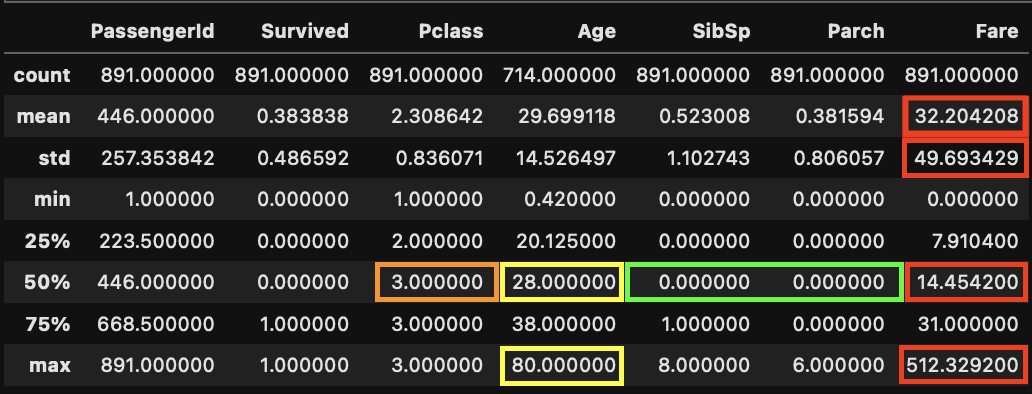

When analyzing numerical features, we will pay attention not only to the mean value but also to the median (50% percentile). The median is more resistant to outliers and often better represents the typical value of a feature. Quantiles show the distribution of the data: the 25th percentile means that a quarter of observations have a value below the specified value, the 50th percentile corresponds to the median, and the 75th percentile shows the value below which three-quarters of observations are located.

Based on the obtained statistical characteristics, we can make the following preliminary conclusions:

- The median value of the `Pclass` feature is 3, which indicates that at least half of the passengers had third class or lower.
- The average age of passengers is around 30 years, while the range of values is quite wide: from infants to passengers aged 80.
- For the `SibSp` and `Parch` features, the median values are equal to 0, which shows that at least half of the passengers traveled without the specified relatives or family members on board.
- The `Fare` feature has a significant range of values. The mean value (32.20) is noticeably higher than the median (14.45), which indicates an asymmetric distribution (i.e., a skewed distribution where one "side" of the data is longer than the other) and a possible influence of high values on the mean. The standard deviation (49.69) significantly exceeds the median value of the feature, which indicates high variability in ticket prices. The maximum `Fare` value is 512.33, which is significantly higher than typical values and may indicate the presence of potential outliers. This feature requires additional analysis before further data processing.

### 3.4 Data Quality Check

Let's check the basic data quality: the presence of missing values and the data types of each column.

In [10]:
# Check data types and missing values in train dataset

train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [11]:
# Check data types and missing values in test dataset

test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


The missing values in the `Age` and `Cabin` features immediately stand out. Next, we will calculate their number and proportion relative to the total number of observations.

In [12]:
# Check missing values count in train dataset

train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [13]:
# Check missing values count in test dataset

test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

The largest number of missing values is found in the `Cabin` feature: 687 (327 in the test dataset) values out of 891 (418 in the test dataset) records. Information about the age of 177 (86 in the test dataset) passengers is also missing. We will calculate the proportion of missing values for these features to assess the scale of the problem.

In [14]:
# Calculate missing values percentage for Age 

train["Age"].isnull().mean() * 100

np.float64(19.865319865319865)

In [15]:
# Calculate missing values percentage for Cabin 

train["Cabin"].isnull().mean() * 100

np.float64(77.10437710437711)

The `Age` feature contains around 20% missing values. This is a significant proportion, but later we can consider different approaches for restoring these values.

The `Cabin` feature contains more than 77% missing values. Such a large amount of missing data may significantly reduce the informativeness of the feature, so its further use requires additional analysis.

In the `Embarked` feature, information about the port of embarkation is missing for only two passengers in the training dataset. This is an insignificant proportion of missing values, which we will analyze in more detail later as part of a separate analysis of this feature.

Now, let's look for possible duplicate records in the data.

In [16]:
# Check duplicated values in train dataset

train.duplicated().sum()

np.int64(0)

In [17]:
# Check duplicated values in test dataset

test.duplicated().sum()

np.int64(0)

No complete duplicate records were found in the datasets.

### 3.5 Conclusions

We have completed the initial data analysis stage. Let's summarize the main observations that will be used for further data processing and model building:

- The dataset contains 12 features: 6 numerical and 6 categorical features;
- The training dataset contains 891 observations, while the test dataset contains 418 observations;
- The `Fare` feature has a significant range of values and potential outliers that need to be considered during further analysis;
- The `Age`, `Embarked`, and `Cabin` features contain missing values, so they require additional processing during the data preparation stage;
- No duplicate records were found in the data.

## 4 Exploratory Data Analysis (EDA)

### 4.1 EDA Overview

During the Exploratory Data Analysis (EDA) stage, we will conduct a detailed examination of the features to understand the structure of the data, identify relationships, outliers, and possible anomalies.

The main goal of EDA is not simply to create a large number of visualizations, but to obtain useful insights that will help us form hypotheses about the influence of features on the target variable `Survived`. During the analysis, we will use only those visualizations that help identify patterns, relationships, and possible anomalies in the data. An excessive number of plots often leads to duplicated information and reduces the overall informativeness of the research.

When analyzing the data, it is important to consider the specifics of the subject area: the "Titanic" disaster. This will allow us not only to visually explore the data but also to interpret the obtained results from the perspective of the real event.

Before starting the analysis, we will create copies of the original datasets. This will allow us to safely modify the data, add temporary features, and conduct experiments without affecting the original datasets.

In [18]:
# Create copies to preserve original datasets during analysis

train_df = train.copy()
test_df = test.copy()

### 4.2 PassengerId

`PassengerId` is a unique passenger identifier. It does not contain information about passenger characteristics and has no direct relationship with the target variable `Survived`, so it will not be used for model training.

At the same time, this column should be stored separately because `PassengerId` is required when creating the prediction file for submission to Kaggle. After preparing the data for the model, this feature will be removed from the training dataset.

It is important to note that not every column in a dataset is a useful feature for model training. If the lack of informative value of a feature is obvious, as in this case, it should not be used when building a model.

### 4.3 Survived (Target)

The target variable `Survived` is the main object of prediction in our classification task.

When analyzing the target variable in classification problems, it is important to determine the type of task (binary or multiclass classification) and study the class distribution. The class balance can affect the choice of evaluation metrics and the interpretation of model performance.

Before visualization, it is useful to examine aggregated values to understand the scale of the data and compare the plot with exact numerical values.

In [19]:
# Display target variable distribution

train_df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In other words, around 62% of passengers did not survive, while the proportion of survivors was approximately 38%.

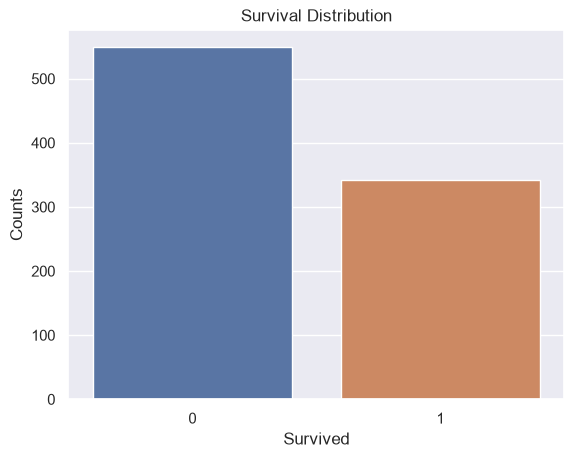

In [20]:
# Visualize the distribution of the target variable

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Counts")

sns.countplot(
    data=train_df, 
    x="Survived", 
    hue="Survived", 
    legend=False
);

The obtained values and visualization allow us to evaluate the distribution of the target variable. Our task is a binary classification problem: the value `0` corresponds to passengers who did not survive, while the value `1` corresponds to survivors. The class distribution is not completely balanced: there are more passengers who did not survive than survivors (549 compared to 342). However, the difference between the classes is not critical, so there is no need to apply data balancing methods at this stage.

Further analysis will focus on studying the relationships between the target variable `Survived` and the remaining features in order to determine which passenger characteristics are associated with the probability of survival.

### 4.4 Passenger Class (Pclass)

The first feature we will analyze is `Pclass` - the passenger ticket class. Although this feature is represented by numerical values, it is categorical because the numbers represent separate categories rather than a quantitative measure.

We assume that `Pclass` may be related to the probability of passenger survival, as the ticket class reflected socio-economic status and could be associated with accommodation conditions on the ship.

First, we will examine the distribution of passengers across different classes. After that, we will compare survival rates between different `Pclass` categories.

In [21]:
# Display the distribution of passengers across ticket classes

train_df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

The `Pclass` feature contains three categories:

- `1` - first class;
- `2` - second class;
- `3` - third class.

Although the feature values are represented by numbers, they do not indicate a quantitative measure. For example, the third class is not "three times larger" than the first class. This is a categorical feature where each value corresponds to a separate group of passengers.

The ticket class reflected the level of accommodation on board and was associated with the passenger's socio-economic status.

The diagram below shows the approximate arrangement of passenger areas on the Titanic.

<div align="center">
<img src="../images/Titanic_cutaway_diagram.png" width="500">
</div>

First-class passenger areas were mainly located on the upper decks (`A`, `B`, `C`), where the most comfortable cabins and public areas were situated. Second-class passengers occupied mostly the middle decks (`D`, `E`), while third-class passengers were primarily accommodated on the lower decks (`E`, `F`, `G`).

This difference in location could affect passengers' access to evacuation areas and therefore could potentially be related to the probability of survival. Further, we will test this hypothesis by analyzing the relationship between `Pclass` and the target variable `Survived`.

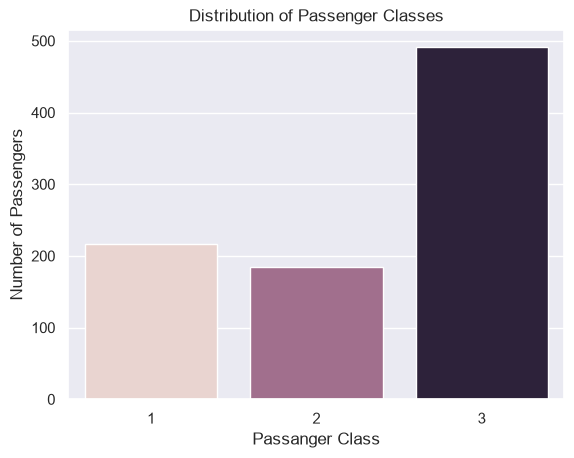

In [22]:
# Visualize the distribution of the passenger classes

plt.title("Distribution of Passenger Classes")
plt.xlabel("Passanger Class")
plt.ylabel("Number of Passengers")

sns.countplot(
    data=train_df,
    x="Pclass",
    hue="Pclass",
    legend=False
);

The distribution of passengers across classes is uneven. The majority of passengers traveled in third class (491 passengers), while the number of passengers in first class (216 passengers) and second class (184 passengers) was significantly lower.

This distribution is important to consider during further analysis, as the size of each category affects the interpretation of the results. In particular, we need to separately investigate whether the probability of survival differs between passengers from different classes.

### 4.5 Pclass vs Survived

The next step is to examine the relationship between `Pclass` and the target variable `Survived` in order to determine whether there are differences in survival rates between passenger classes.

Based on the previous analysis, we can formulate the following hypothesis: **"Passengers from higher classes had a higher probability of survival compared to passengers from lower classes."**

In [23]:
# Calculate survival rate for each passenger class

train_df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

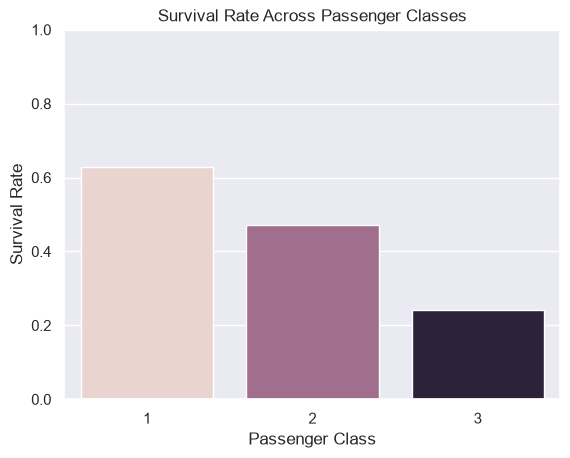

In [24]:
# visualisation probability of Pclass

plt.title("Survival Rate Across Passenger Classes")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

sns.barplot(
    data=train_df,
    x="Pclass",
    y="Survived",
    hue="Pclass",
    ci=False,
    legend=False
);

The results of the analysis confirm the proposed hypothesis: the survival rate of passengers differed depending on the ticket class.

The distribution of the proportion of survivors by class:
- first class - around 63%;
- second class - around 47%;
- third class - around 24%.

Although third-class passengers represented the largest group in the dataset, their survival rate was significantly lower compared to passengers from the first and second classes.

Thus, there is a relationship between `Pclass` and the probability of survival: passengers from higher classes, on average, had a greater chance of survival. However, it is important to consider that `Pclass` may reflect not only the level of accommodation on board but also other related characteristics, such as socio-economic status. Therefore, this feature should be analyzed together with other variables during further analysis.

### 4.6 Passenger Name and Title Analysis (Name)

The `Name` feature contains the full passenger name and belongs to the category of text features.

Due to the large number of unique values, directly using the full name as a feature is not effective: most values appear only once and do not allow us to identify stable patterns.

However, the name contains additional information - the title (`Title`), which may be related to the passenger's gender, age, marital status, and social status.

To analyze the distribution of categories, the analysis was performed separately on the training dataset, since all research conclusions and pattern identification should be based only on the data available to the model during training.

Additionally, the distribution of extracted titles was checked in the test dataset to ensure that no unknown categories would appear after further feature processing when applying the model to new data.

In [25]:
# Extract passenger titles from the Name column in the training set for feature analysis

title_series_train = train_df["Name"].str.extract(r',\s*([^.]*)\.')[0]

title_series_train.value_counts()

0
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [26]:
# Extract passenger titles from the Name column in the test set
# to verify that the same title categories exist before applying feature transformations

title_series_test = test_df["Name"].str.extract(r',\s*([^.]*)\.')[0]

title_series_test.value_counts()

0
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64

As a result of the analysis, it was found that some titles occur extremely rarely and cannot be reliably evaluated as separate categories due to the small number of observations. During the Feature Engineering stage, these categories will be combined into a single group. This will allow us to preserve information about the presence of an uncommon title, reduce the number of categories, and improve the stability of the feature during model training.

The obtained values represent the categories of titles found in the names of passengers from the training dataset:

- `Mr` - Mister, a title used for adult men;
- `Miss` - a title used for unmarried women and young women;
- `Mrs` - Mistress, a title used for married women;
- `Master` - a title used for boys or young men;
- `Dr` - Doctor, passengers with an academic or medical degree;
- `Rev` - Reverend, representatives of the clergy;
- `Major` - military rank of major;
- `Mlle` - French abbreviation for Mademoiselle, equivalent to Miss;
- `Col` - Colonel, military rank;
- `Don` - Spanish honorary title for men;
- `Mme` - French abbreviation for Madame, equivalent to Mrs;
- `Ms` - neutral title for women without indicating marital status;
- `Lady` - aristocratic title;
- `Sir` - knightly title or honorary title;
- `Capt` - Captain, military rank;
- `the Countess` - countess, aristocratic title;
- `Jonkheer` - Dutch noble title.

Most passengers have standard titles (`Mr`, `Miss`, `Mrs`, `Master`), while the remaining categories occur very rarely or are unique.

Rare titles may contain potentially useful information about the passenger's social status, but their number is insufficient for reliable comparison of survival rates between individual groups. A small sample size can lead to unstable results and distort conclusions. Therefore, during the Feature Engineering stage, rare categories will be combined into a single `Rare` group. This approach will allow us to preserve information about the presence of an uncommon title, reduce the number of categories, and make the feature more stable for further model training.

Let's formulate a new hypothesis: **"Passengers with different titles in their names had different survival rates because the title may indirectly reflect the passenger's age, gender, and social status."**

Now we can compare the probability of survival between the main categories of the `Title` feature.

In [27]:
# Create a temporary dataset with extracted passenger titles for EDA analysis

title_analysis_df = train_df.assign(
    Title=title_series_train
)

In [28]:
# Calculate passenger count and average survival rate for each title category

title_stats = (
    title_analysis_df
    .groupby("Title")
    .agg(
        PassangerCount=("Survived", "count"),
        SurvivalRate=("Survived", "mean")
    )
    .reset_index()
)

title_stats

,Title,PassangerCount,SurvivalRate
0,Capt,1,0.000000
1,Col,2,0.500000
2,Don,1,0.000000
3,Dr,7,0.428571
4,Jonkheer,1,0.000000
5,Lady,1,1.000000
6,Major,2,0.500000
7,Master,40,0.575000
8,Miss,182,0.697802
9,Mlle,2,1.000000


In [29]:
# Convert survival probability into percentage format for easier interpretation

title_stats["SurvivalRate"] *= 100

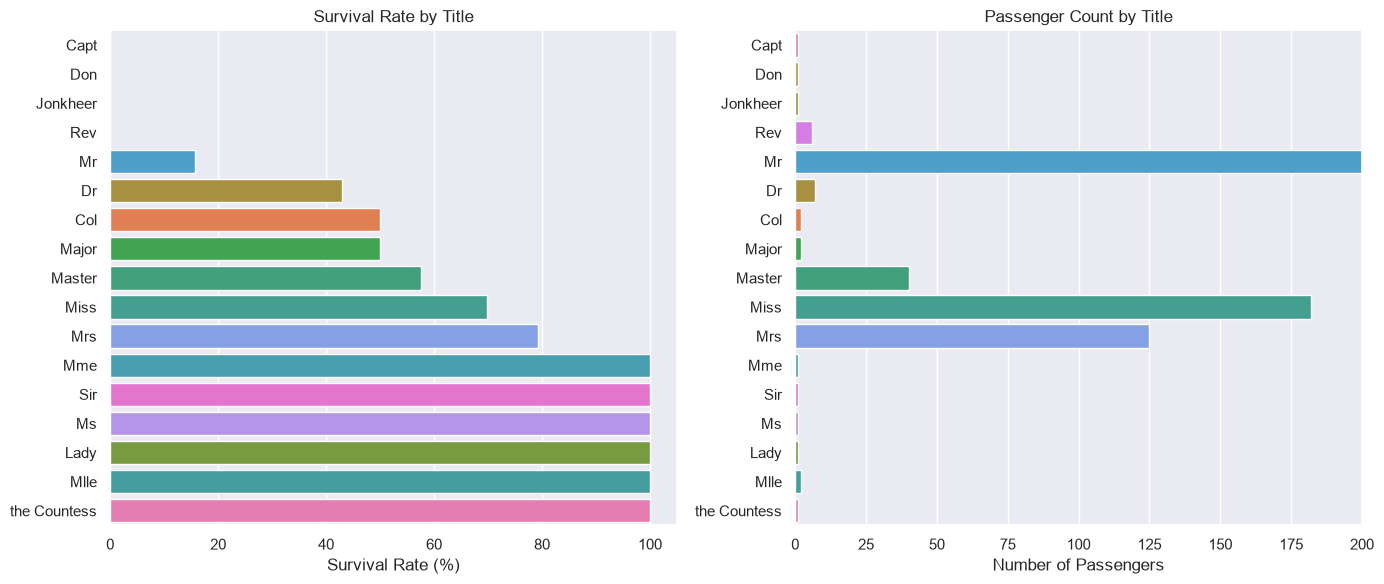

In [30]:
# Visualize survival rate and passenger count across title categories

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

# Sort titles by survival rate to make differences between categories easier to compare

order = (
    title_stats
    .sort_values("SurvivalRate")
    ["Title"]
)

sns.barplot(
    data=title_stats,
    x="SurvivalRate",
    y="Title",
    hue="Title",
    order=order,
    ax=ax1
)

sns.barplot(
    data=title_stats,
    x="PassangerCount",
    y="Title",
    hue="Title",
    order=order,
    ax=ax2
)


ax1.set_title("Survival Rate by Title")
ax1.set_xlabel("Survival Rate (%)")
ax1.set_ylabel("")

ax2.set_title("Passenger Count by Title")
ax2.set_xlabel("Number of Passengers")
ax2.set_ylabel("")
ax2.set_xlim(0, 200)


fig.tight_layout();

The most common titles demonstrate noticeable differences in survival rates:

- passengers with the titles `Mrs` and `Miss` had higher survival rates;
- the `Mr` group, which is the largest group, had a significantly lower survival rate;
- passengers with the title `Master` also showed a higher survival rate compared to most male groups.

For rare and unique titles (`Lady`, `Sir`, `the Countess`, `Jonkheer`, and others), it is impossible to make reliable conclusions due to the small number of observations. Therefore, it is reasonable to combine them into a single group in further processing.

Thus, the extracted `Title` feature contains potentially useful information and may reflect passenger characteristics related to social status, age, and gender.

### 4.7 Passenger Gender (Sex)

The `Sex` feature contains information about the passenger's gender.

At the first stage, we will examine the distribution of passengers across categories in order to evaluate the balance of the feature before further analysis of its relationship with the target variable `Survived`.

In [31]:
# Calculate passenger count by sex

train_df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

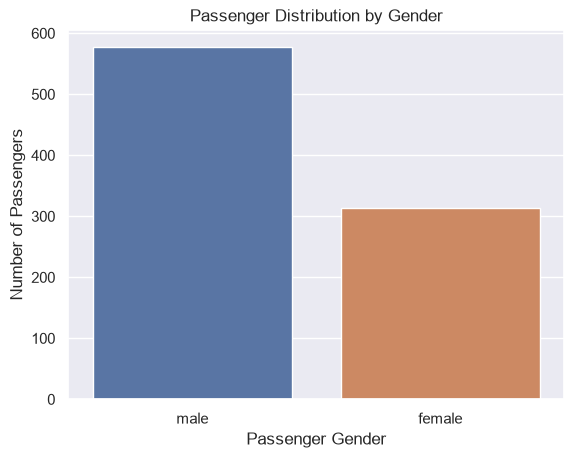

In [32]:
# Visualize passenger distribution by gender

plt.title("Passenger Distribution by Gender")
plt.xlabel("Passenger Gender")
plt.ylabel("Number of Passengers")

sns.countplot(
    data=train_df,
    x="Sex",
    hue="Sex",
    legend=False
);

Although men represented the majority of passengers in the dataset, the distribution of the feature alone is not sufficient to evaluate its influence on survival.

The next step is to examine the relationship between `Sex` and the target variable `Survived` in order to determine whether the survival rate differed between men and women.

### 4.8 Sex vs Survival

Let's formulate the hypothesis: **"Female passengers had a higher survival rate compared to male passengers."**

To test this hypothesis, we will compare the average survival rate between the two categories of the `Sex` feature.

In [33]:
# Calculate survival rate for each gender group

train_df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

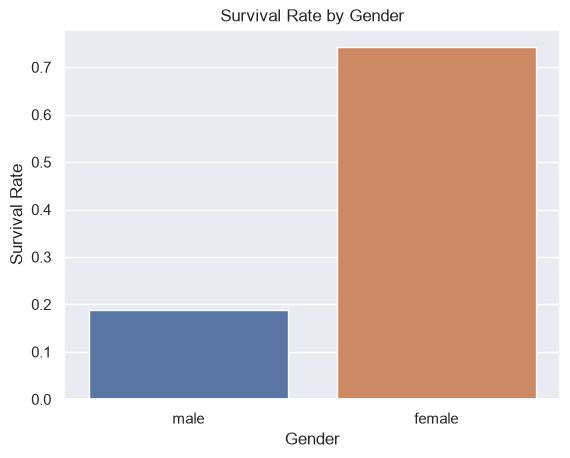

In [34]:
# Visualize survival rate across gender groups

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

sns.barplot(
    data=train_df,
    x="Sex",
    y="Survived",
    hue="Sex",
    ci=False,
    legend=False,
);

The results of the analysis are consistent with the proposed hypothesis: the survival rate differed significantly between men and women. Women had a higher survival rate - around 74%, while the rate among men was approximately 19%. However, this relationship does not mean that gender was the only factor determining survival. Other passenger characteristics, such as ticket class, age, or social status, could also influence the result. It is also necessary to consider possible relationships between features. For example, the distribution of men and women across passenger classes may have been different, which could additionally affect the probability of survival.

Historically, the principle of "women and children first" was followed on board the "Titanic", but within data analysis we cannot rely only on historical information - we will test this statement statistically.

The next step is to examine the combined influence of the `Pclass` and `Sex` features on survival rate in order to determine whether the observed trend remains when multiple characteristics are considered simultaneously.

### 4.9 Pclass and Sex vs Survival

Let's formulate the following hypothesis: **"The difference in survival rates between men and women remains within each ticket class, while passengers from higher classes have an advantage regardless of gender."**

We will compare the probability of survival between passengers of different genders within each `Pclass` category.

In [35]:
# Calculate survival probability by passenger class and sex

pclass_sex_stats = (
    train_df
    .groupby(["Pclass", "Sex"])['Survived']
    .mean()
    .to_frame()
)

pclass_sex_stats

Survived
Pclass Sex             
1      female  0.968085
       male    0.368852
2      female  0.921053
       male    0.157407
3      female  0.500000
       male    0.135447

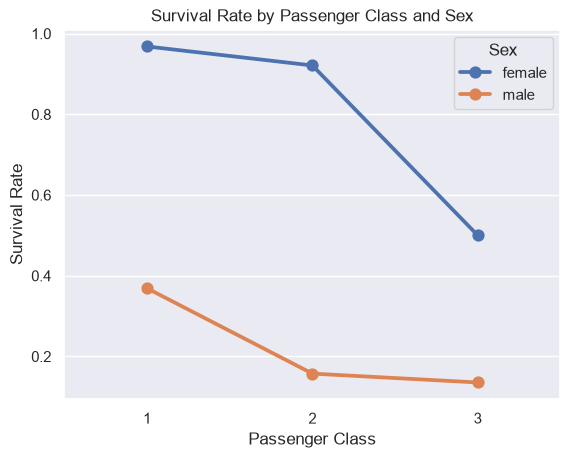

In [36]:
# Visualize survival rates by passenger class and gender

plt.title("Survival Rate by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

sns.pointplot(
    data=train_df,
    x="Pclass",
    y="Survived",
    hue="Sex",
    errorbar=None
);

The obtained results are consistent with the proposed hypothesis.

In all `Pclass` categories, women had a significantly higher survival rate compared to men:

- in the first class, the probability of survival for women was close to 100%, and in the second class, women also maintained a significant advantage;
- in the third class, the overall survival rate was lower for both genders.

Thus, the analysis shows that `Sex` and `Pclass` are related to the probability of survival. Considering them together allows us to see a more complex picture: both the passenger's gender and social status simultaneously influenced the chance of survival.

### 4.10 Passenger Age (Age)

Next, we will analyze the `Age` feature.

As we previously observed in `describe()`, the dataset contains passengers across a wide age range: from infants to people over 80 years old. Therefore, it is important to study the distribution of the `Age` feature and identify its main characteristics.

We also identified around 20% of missing values in the `Age` feature, which will need to be considered separately during the data preprocessing stage.

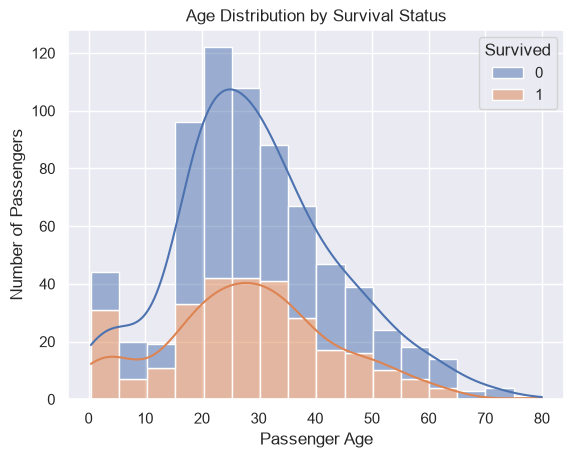

In [37]:
# Display age distribution by survival status

plt.title("Age Distribution by Survival Status")
plt.xlabel("Passenger Age");
plt.ylabel("Number of Passengers")

sns.histplot(
    data=train_df, 
    x="Age", 
    hue="Survived",
    multiple="stack",
    kde=True, 
    binwidth=5
);

The histogram shows that the majority of passengers were within the approximate age range of 20 to 40 years. It is also noticeable that the number of survivors is significantly lower than the number of passengers who did not survive, which corresponds to the overall class distribution of the target variable `Survived`.

Previously, in `describe()`, we also noticed a possible right-skewed distribution: most values are concentrated on the left side of the graph, while a long tail can be observed on the right. This is caused by the presence of a small number of elderly passengers.

When working with features that have this type of distribution, logarithmic transformation is sometimes applied to reduce the influence of large values. However, for passenger age, such a transformation requires careful consideration because age has a natural meaning and is already measured on an appropriate scale.

### 4.11 Age vs Survived

Next, we will examine the relationship between passenger age and the probability of survival. We will formulate the following hypothesis: **"Children had a higher chance of survival compared to adult passengers."**

Since the age distribution is not uniform and the number of elderly passengers is significantly smaller, we will divide the `Age` feature into 5-year intervals. This will allow us to compare survival rates between age groups and reduce the influence of small groups.

In [38]:
# Calculate survival rate by age groups

age_bins = np.arange(0, 86, 5)

age_stats = (
    train_df
    .assign(
        AgeGroup=pd.cut(
            train_df["Age"],
            bins=age_bins,
            right=False,
            include_lowest=True
        )
    )
    .groupby("AgeGroup")["Survived"]
    .agg(
        PassengerCount="count",
        SurvivedCount="sum",
        SurvivalRate="mean"
    )
    .reset_index()
)

age_stats

,AgeGroup,PassengerCount,SurvivedCount,SurvivalRate
0,"[0, 5)",40,27,0.675000
1,"[5, 10)",22,11,0.500000
2,"[10, 15)",16,7,0.437500
3,"[15, 20)",86,34,0.395349
4,"[20, 25)",114,39,0.342105
5,"[25, 30)",106,38,0.358491
6,"[30, 35)",95,40,0.421053
7,"[35, 40)",72,33,0.458333
8,"[40, 45)",48,18,0.375000
9,"[45, 50)",41,16,0.390244


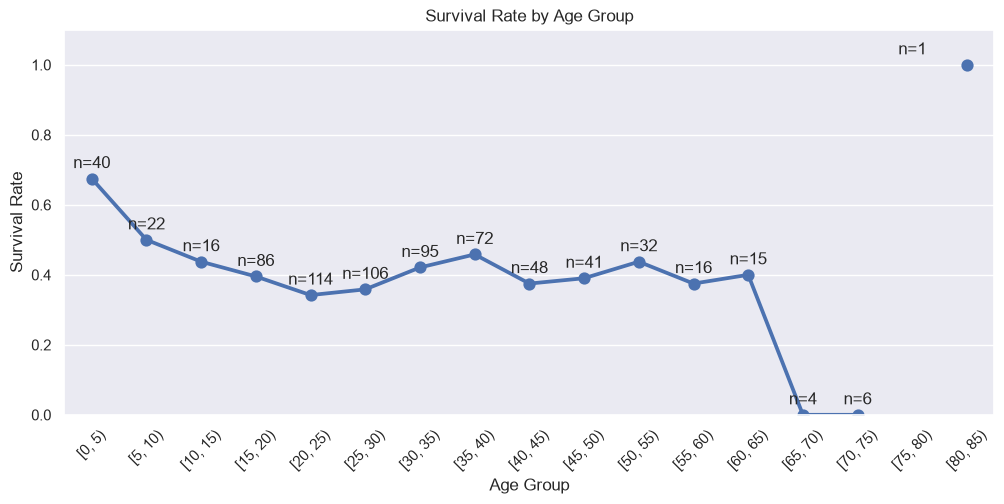

In [39]:
# Visualize survival rate by age group

plt.figure(figsize=(12, 5))

ax = sns.pointplot(
    data=age_stats,
    x="AgeGroup",
    y="SurvivalRate",
    errorbar=None
)

for index, row in age_stats.iterrows():
    ax.text(
        index,
        row["SurvivalRate"] + 0.03,
        f'n={row["PassengerCount"]}',
        ha="center"
    )

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.ylim(0, 1.1)
plt.xticks(rotation=45);

The obtained results show that younger age groups indeed had a higher survival rate.

Passengers under 10 years old demonstrated a survival probability of around 50% or higher, while after this age a decrease in the survival rate can be observed in most age groups. However, we cannot conclude that survival depended directly only on the `Age` feature. The results are strongly influenced by other factors, such as `Sex`, `Pclass`, and the number of passengers within each age group.

Special attention should be paid to groups with a small number of observations. For example, a high survival rate in older age categories may be related not to age itself as a factor, but to the small sample size.

Thus, age can be a useful feature for the model, but its influence should be considered together with other passenger characteristics.

### 4.12 Sex, Pclass and Age vs Survival

Now we will examine the combined influence of several features: `Age`, `Pclass`, and `Sex`.

Previously, we mainly used categorical comparisons with `barplot`, as they are well suited for analyzing individual groups. However, age is a continuous feature, so for a more detailed analysis we need to consider the distribution of values within each category.

Let's test the following hypothesis: **"Passenger age influenced the probability of survival within different classes and genders, but the effect of age differed between passenger groups."**

For this purpose, we will use `violinplot`, which allows us to compare the age distribution among survived and deceased passengers within different categories.

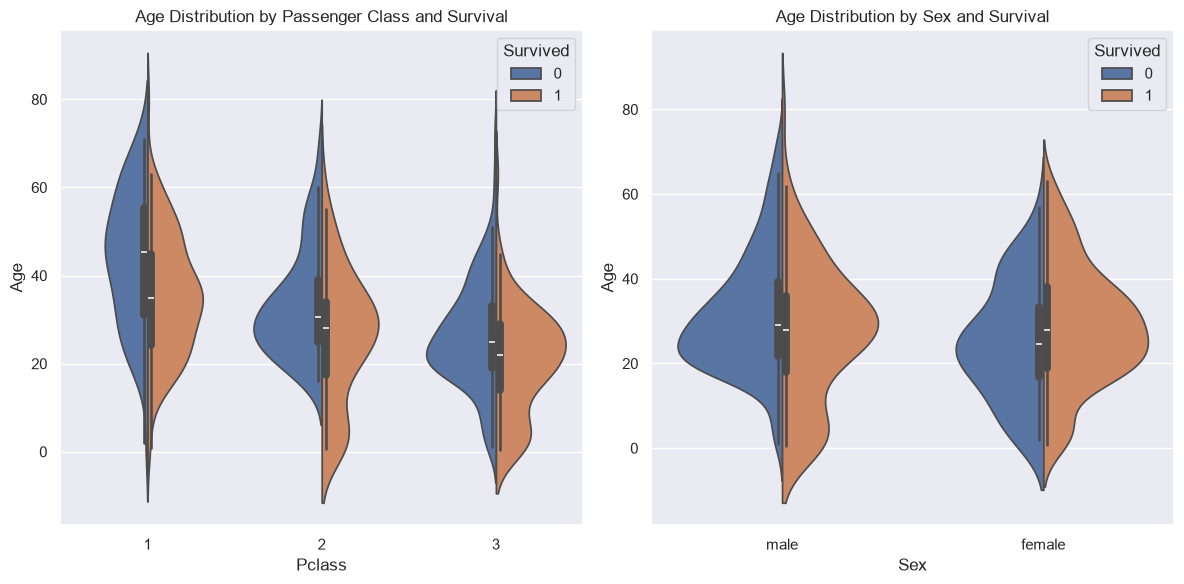

In [40]:
# Compare age distribution by passenger class, sex, and survival status

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

sns.violinplot(
    data=train_df,
    x="Pclass",
    y="Age",
    hue="Survived",
    split=True,
    ax=ax1,
)

sns.violinplot(
    data=train_df, 
    x="Sex", 
    y="Age", 
    hue="Survived", 
    split=True, 
    ax=ax2,
)

ax1.set_title("Age Distribution by Passenger Class and Survival")

ax2.set_title("Age Distribution by Sex and Survival")

plt.tight_layout();

Thanks to the visualization, we can observe several patterns:

- in the first class, passengers were generally older, and there were significantly fewer children compared to the second and third classes;
- among survived passengers, differences in age distribution can be observed between groups; however, age alone does not explain the probability of survival;
- women and children had a higher survival rate compared to other passenger groups, which confirms the importance of the `Sex` and `Age` features when analyzing survival;
- the influence of age should be considered together with other features, especially `Sex` and `Pclass`, since the combination of factors better explains the differences in survival rates.

### 4.13 Family Members Aboard: SibSp and Parch

Let's consider two features related to the passenger's family environment: `SibSp` and `Parch`. These features have a similar meaning, as both represent the number of relatives of the passenger who were on board.

Instead of analyzing each feature separately, we will examine them together and test the following general hypothesis: **"Most passengers traveled without relatives, and family size could influence the probability of survival."**

First, we will study the distribution of these features, and then combine them into `FamilySize`, which will allow us to evaluate the total family size of the passenger.

In [41]:
# Calculate passenger count by siblings

train_df["SibSp"].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

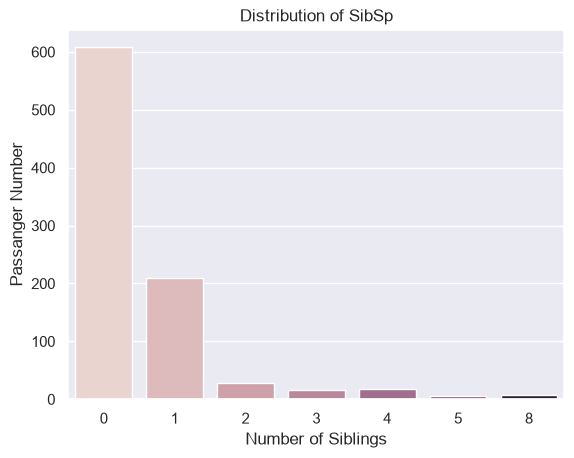

In [42]:
# Display distribution of siblings and spouses aboard

plt.title("Distribution of SibSp")
plt.xlabel('Number of Siblings')
plt.ylabel('Passanger Number')

sns.countplot(
    data=train_df,
    x="SibSp",
    hue="SibSp",
    legend=False
);

In [43]:
# Calculate passenger count by siblings

train_df["Parch"].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

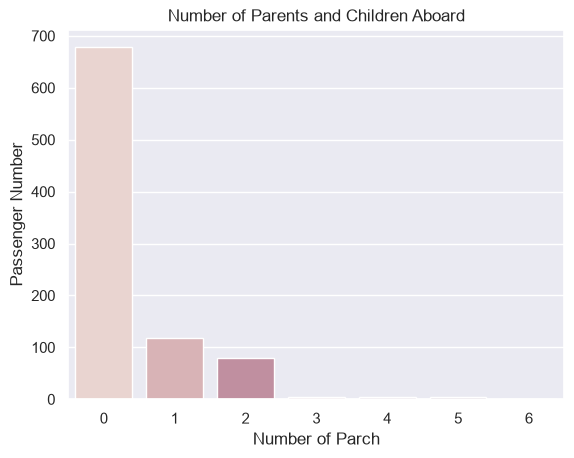

In [44]:
# Display distribution of parents and children aboard

plt.title("Number of Parents and Children Aboard")
plt.xlabel('Number of Parch')
plt.ylabel('Passenger Number')

sns.countplot(
    data=train_df,
    x="Parch",
    hue="Parch",
    legend=False
);

The analysis of the distribution shows that most passengers traveled without relatives on board. Both features have a strong concentration around zero values and a small number of rare cases with a large number of relatives. Such rare values can make the interpretation of individual features more difficult, so the next step will be to combine `SibSp` and `Parch` into a combined potential feature `FamilySize` and examine its relationship with survival.

### 4.14 Family Size vs Survival

After combining the `SibSp` and `Parch` features, we will create a new feature `FamilySize`, which represents the total size of the passenger's family group, and examine how family size is related to the probability of survival.

In [45]:
# Calculate survival rate by family size

family_size_stats = (
    train_df
    .assign(FamilySize=train_df["SibSp"] + train_df["Parch"] + 1)
    .groupby(["FamilySize"])["Survived"]
    .agg(
        PassengerCount="count",
        SurvivalRate="mean"
    )
    .reset_index()
)

family_size_stats

,FamilySize,PassengerCount,SurvivalRate
0,1,537,0.303538
1,2,161,0.552795
2,3,102,0.578431
3,4,29,0.724138
4,5,15,0.200000
5,6,22,0.136364
6,7,12,0.333333
7,8,6,0.000000
8,11,7,0.000000


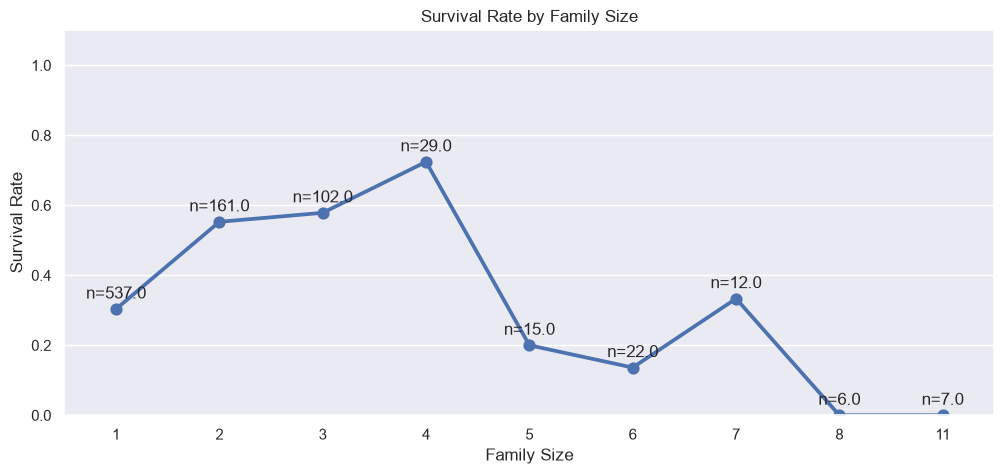

In [46]:
# Visualize survival rate depending on family size and show sample size (n)

plt.figure(figsize=(12, 5))

ax = sns.pointplot(
    data=family_size_stats,
    x="FamilySize",
    y="SurvivalRate",
    errorbar=None
)

for index, row in family_size_stats.iterrows():
    ax.text(
        index,
        row["SurvivalRate"] + 0.03,
        f'n={row["PassengerCount"]}',
        ha="center"
    )

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.ylim(0, 1.1);

Now we can evaluate the relationship between family size and the probability of survival.

Main observations:

- Passengers who traveled alone (`FamilySize = 1`) had a lower survival rate compared to passengers traveling in small family groups.
- The highest survival rate was observed among passengers with a family size between 2 and 4 people.
- For large family groups (`FamilySize >= 5`), the probability of survival decreased.
- Groups with larger family sizes contain fewer observations, so the results for these categories should be interpreted with caution.

Thus, family group size can be a useful feature for the model, but its influence should be considered together with other passenger characteristics.

### 4.15 Ticket

The `Ticket` feature contains a large number of unique values, which makes it inconvenient for direct use in linear models.

When applying one-hot encoding, a large number of categories can lead to the creation of a sparse feature matrix and the appearance of multicollinearity.

Although ticket information could potentially be useful for some models, such as decision trees, in the current analysis we will remove the original `Ticket` feature during the data preprocessing stage.

### 4.16 Fare

During the initial data analysis in `describe()`, we noticed that the standard deviation of the `Fare` feature exceeds its mean value. This may indicate a large spread of values, the presence of outliers, and an asymmetric distribution. Therefore, we will first examine the distribution of ticket fares and check for extreme values.

In [47]:
# Generate descriptive statistics for Fare

train_df["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

The maximum ticket fare value is around 512 dollars, which differs significantly from the majority of observations.

Let's examine the distribution of the feature and build a Q-Q plot to visually assess how much the data deviates from a normal distribution.

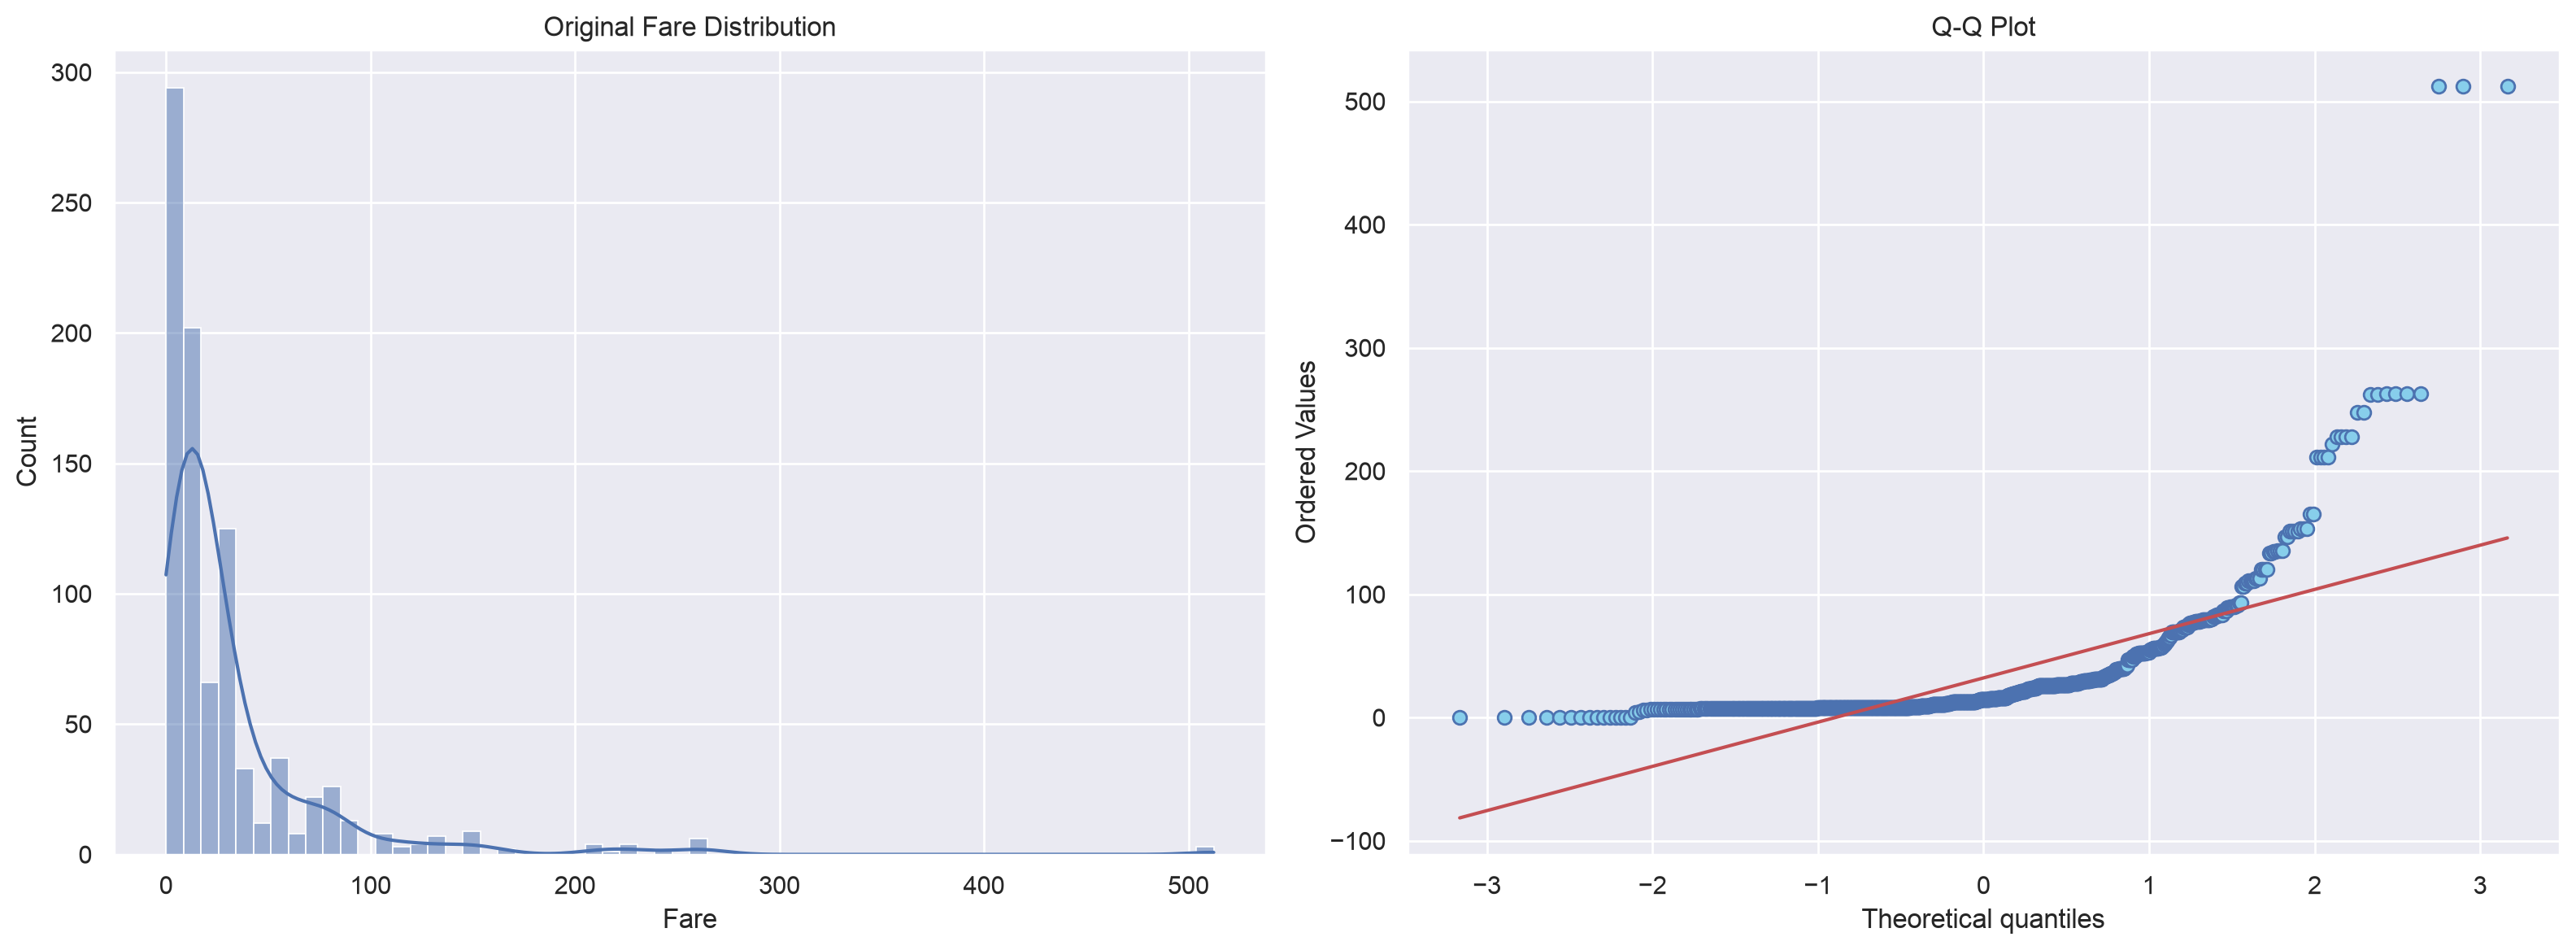

In [48]:
# Visualize Fare distribution and Q-Q plot

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=200)

sns.histplot(train_df["Fare"], kde=True, ax=axes[0])
axes[0].set_title("Original Fare Distribution")
axes[0].set_xlabel("Fare")

stats.probplot(train_df["Fare"], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot")
axes[1].get_lines()[0].set_markerfacecolor('skyblue')

plt.tight_layout();

The distribution of the `Fare` feature differs significantly from a normal distribution. A strong right skew can be observed: most passengers had relatively low ticket fares, while a small number of passengers purchased significantly more expensive tickets. The main concentration of values is approximately within the range from 0 to 31 dollars.

As mentioned earlier, features with strong right skew are often transformed using logarithmic transformation to reduce the influence of extreme values and make the distribution more suitable for modeling. During the preprocessing stage, we should consider applying this transformation to the `Fare` feature.

### 4.17 Fare vs Survived

Let's formulate the hypothesis: **"Passengers with higher ticket fares had a higher probability of survival."**

We will check whether the distribution of `Fare` differs between survived and deceased passengers.

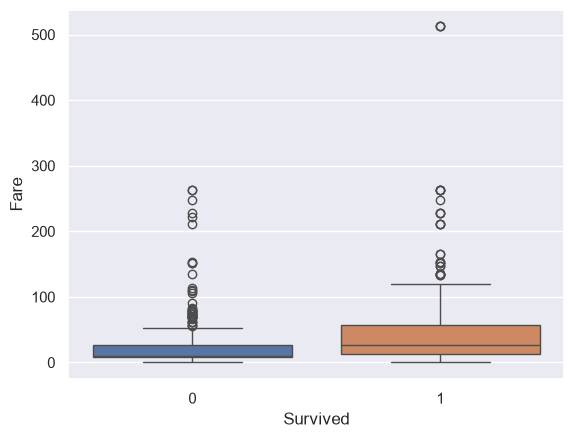

In [49]:
# Compare ticket fare distribution between survived and non-survived passengers
# to identify differences in median values and potential outliers

sns.boxplot(
    data=train_df,
    x="Survived",
    y="Fare",
    hue="Survived",
    legend=False
);

The boxplot shows that the median ticket fare among survived passengers was higher than among deceased passengers. The survived group also demonstrates a wider range of values, indicating greater variability in ticket prices. Both groups contain a large number of outliers, so we will separately examine passengers with the maximum ticket fare of 512 dollars.

In [50]:
# Select passengers with extremely high ticket fares

train_df[train_df["Fare"] > 500]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C


There are three passengers who purchased tickets with the same number. At first glance, we might assume that they were relatives; however, the `SibSp` and `Parch` features do not support this hypothesis. It is important to consider the specifics of ticket organization on the "Titanic". A single ticket number does not always indicate a family relationship between passengers. Joint ticket purchases could have been made by friends, colleagues, or fellow travelers who bought tickets through the same agent. Additionally, first-class passengers could have shared a ticket number with accompanying staff, such as servants, maids, or valets. Therefore, we should not automatically interpret the same ticket number as a family connection.

However, it is important to consider that `Fare` is strongly related to `Pclass`. The high ticket price largely reflects the passenger's belonging to a higher service class, so some information from these features may overlap. For this reason, we will not perform additional extensive analysis of the relationships involving the `Fare` feature.

### 4.18 Cabin

Previously, we noticed that around 77% of the values in the `Cabin` feature are missing. Most likely, this is not an error, but an indication that the passenger simply did not have an individual cabin. To verify this assumption, let's examine the distribution of cabins across different passenger classes.

The logic is straightforward: most people on board traveled in the third class and, due to financial limitations, could not afford a private cabin. These passengers may have formed the majority of the missing values. If this relationship is confirmed, we will be able to test the key dependency: **"Did having a private cabin increase a passenger's chances of survival?"**

In [51]:
# Calculate survival rate depending on Cabin availability

cabin_stat = (
    train_df
    .assign(HasCabin=train_df["Cabin"].notna())
    .groupby(["HasCabin", "Pclass"])["Survived"]
    .agg(
        PassengerCount="count", 
        SurvivalRate="mean"
    )
)

cabin_stat

PassengerCount  SurvivalRate
HasCabin Pclass                              
False    1                   40      0.475000
         2                  168      0.440476
         3                  479      0.235908
True     1                  176      0.664773
         2                   16      0.812500
         3                   12      0.500000

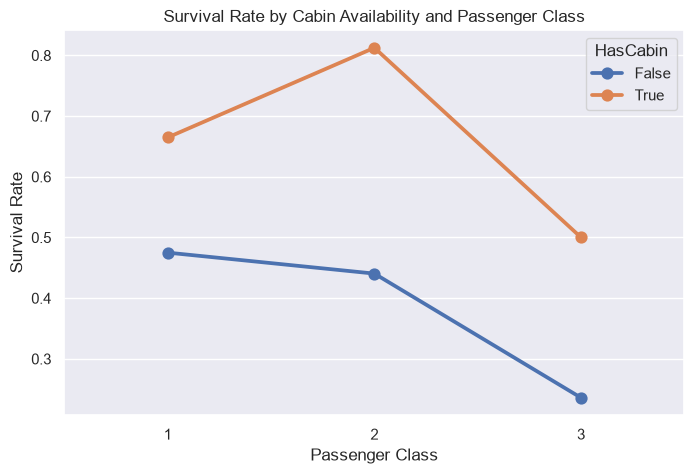

In [52]:
# Visualize survival rate depending on Cabin availability and passenger class

plt.figure(figsize=(8, 5))

sns.pointplot(
    data=cabin_stat.reset_index(),
    x="Pclass",
    y="SurvivalRate",
    hue="HasCabin",
    errorbar=None
)

plt.title("Survival Rate by Cabin Availability and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

The graph shows that having cabin information is associated with a higher survival rate among passengers across all passenger classes. The difference is especially noticeable among first- and second-class passengers, where passengers with a known cabin had higher survival rates. However, it is important to consider that the number of observations with a filled `Cabin` feature differs significantly between classes. For example, in the second and third classes, the number of passengers with known cabin information is much smaller, making the comparison less stable.

The cabin data contains information about the deck where the passenger's cabin was located. Although the full cabin number contains many unique values, the first letter may reflect the location of the cabin on the ship. Therefore, we will extract the first letter from the `Cabin` feature as a potential new feature.

Before using this feature, we will check whether there is a relationship between the deck and the probability of passenger survival. For this purpose, we will calculate the average survival rate for each deck separately within each passenger class (`Pclass`).

In [53]:
# Extract the first letter from Cabin to identify the deck
# Fill missing values with "Unknown" because some passengers have no cabin information

deck_stats = (
    train_df
    .assign(Deck=train_df["Cabin"].str[0].fillna("Unknown"))
    .groupby(["Deck", "Pclass"])["Survived"]
    .agg(
        PassengerCount="count",
        SurvivalRate="mean"
    )
)

deck_stats

PassengerCount  SurvivalRate
Deck    Pclass                              
A       1                   15      0.466667
B       1                   47      0.744681
C       1                   59      0.593220
D       1                   29      0.758621
        2                    4      0.750000
E       1                   25      0.720000
        2                    4      0.750000
        3                    3      1.000000
F       2                    8      0.875000
        3                    5      0.200000
G       3                    4      0.500000
T       1                    1      0.000000
Unknown 1                   40      0.475000
        2                  168      0.440476
        3                  479      0.235908

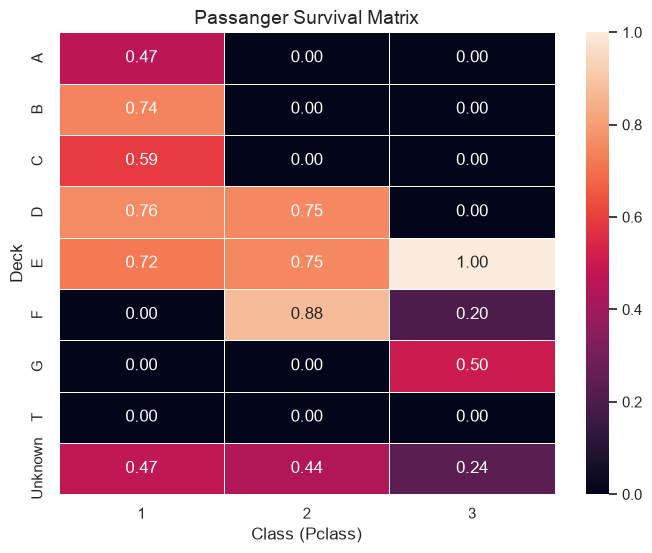

In [54]:
# Transform data into a matrix: rows are Deck values, columns are passenger classes
# Fill missing combinations with zero

matrix = deck_stats.reset_index().pivot(
    index='Deck', 
    columns='Pclass', 
    values='SurvivalRate'
).fillna(0)

plt.figure(figsize=(8, 6))
sns.heatmap(
    matrix, 
    annot=True,      
    fmt=".2f",      
    vmin=0, vmax=1, 
    linewidths=0.5
)

plt.title('Passanger Survival Matrix', fontsize=14)
plt.xlabel('Class (Pclass)', fontsize=12)
plt.ylabel('Deck', fontsize=12);

The graph shows that the probability of survival differs between various decks. Some decks demonstrate higher survival rates; however, these values cannot be interpreted directly due to the small number of passengers in certain groups. For example, decks with a small number of passengers may show a high `SurvivalRate` by chance, so it is important to consider the group size (`PassengerCount`). Additionally, the large number of missing values in `Cabin` leads to the creation of the `Unknown` category, which also contains useful information: the absence of cabin data may be associated with a lower class of accommodation.

### 4.19 Embarked

The `Embarked` feature represents the port where the passenger boarded the ship.

The dataset contains three values:

- `S` — Southampton;
- `C` — Cherbourg;
- `Q` — Queenstown.

Before analyzing the influence of this feature on the probability of survival, it is necessary to understand the structure of passengers from each port. Differences in survival rates may be related not to the boarding port itself, but to the characteristics of passengers who departed from different locations.

In [55]:
# Calculate the number of passengers for each embarkation port

train_df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

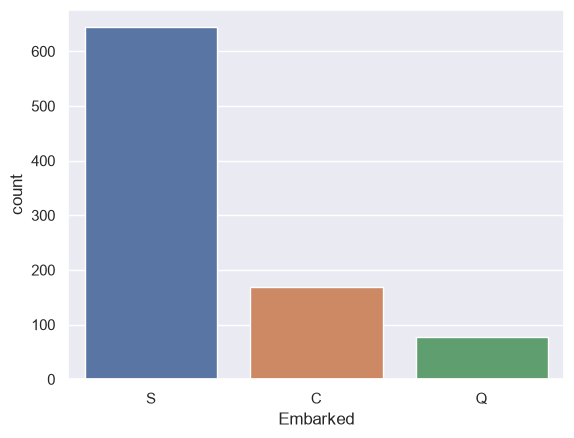

In [56]:
sns.countplot(
    data=train_df,
    x="Embarked",
    hue="Embarked",
    legend=False
);

Most passengers boarded the ship in Southampton (`S`). This port represents the main source of passengers in the dataset.

However, the passenger count distribution alone does not show the relationship between the `Embarked` feature and survival. The next step is to check whether the passenger composition differed between boarding ports.

Historically, the Titanic followed the route:

`Southampton → Cherbourg → Queenstown → New York`

The boarding ports had different passenger compositions:

- `Southampton` - the main boarding port, where the majority of passengers boarded;
- `Cherbourg` - a port with a higher proportion of first-class passengers;
- `Queenstown` - a port where third-class passengers predominated.

Therefore, differences in survival rates between ports may be related to the social composition of passengers.

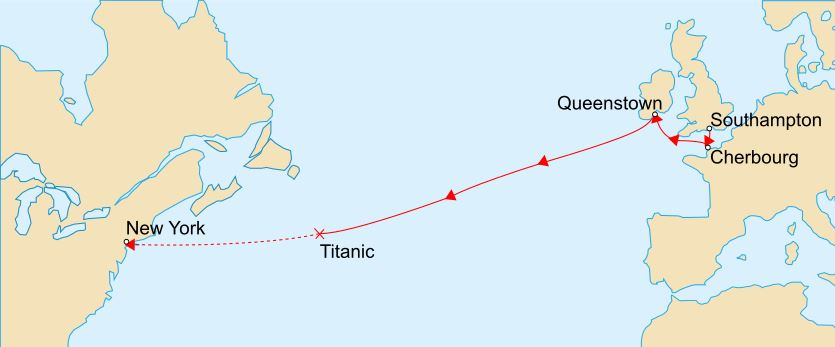

Проверим распределение классов пассажиров внутри каждого порта посадки.

In [57]:
# Compare passenger class distribution across embarkation ports

train_df.pivot_table(index='Embarked', columns='Pclass', values='PassengerId', aggfunc='count')

Pclass,1,2,3
Embarked,,,
C,85,17,66
Q,2,3,72
S,127,164,353


Визуализируем распределение классов пассажиров для каждого порта посадки.

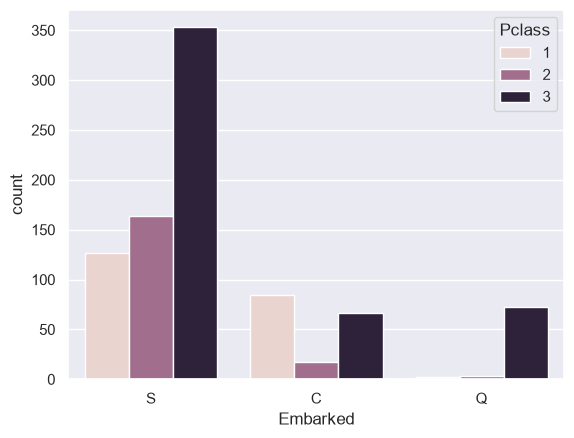

In [58]:
# Visualize passenger class distribution by embarkation port

sns.countplot(
    data=train_df,
    x="Embarked",
    hue="Pclass"
);

The graph confirms that the passenger composition differs between the boarding ports.

Cherbourg (`C`) indeed has a higher proportion of first-class passengers compared to the other ports. Southampton (`S`) has a significantly larger number of third-class passengers.

Since passenger class is one of the key factors associated with survival, the differences in survival rates between ports may be explained by differences in passenger composition rather than the port of embarkation itself.

In [59]:
# Calculate average survival rate for each embarkation port

train_df[["Embarked", "Survived"]].groupby("Embarked").mean()

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.336957


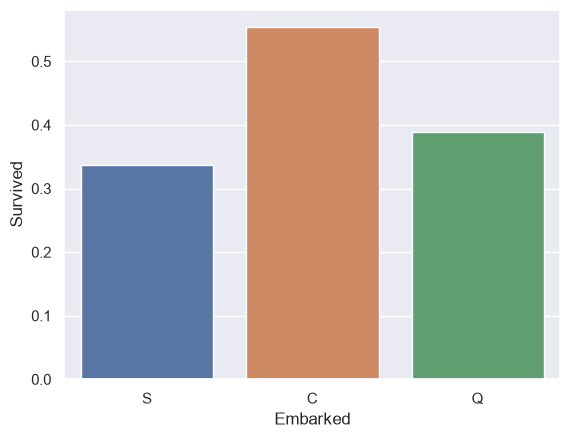

In [60]:
# Visualize survival rate by embarkation port

sns.barplot(
    data=train_df,
    x="Embarked",
    y="Survived",
    hue="Embarked",
    ci=False,
    legend=False
);

At first glance, passengers who boarded in Cherbourg (`C`) had a higher survival rate. However, additional analysis shows that this difference is related to the characteristics of passengers from each port. Cherbourg had a higher proportion of first-class passengers, who initially had a greater chance of survival. Therefore, `Embarked` is associated with survival, but this relationship does not necessarily represent a direct influence of the boarding port itself. Most likely, the feature reflects differences in the social composition of passengers.

During model preparation, the `Embarked` feature should not be removed automatically. Its influence should be evaluated together with other features, as it may contain additional information useful for classification.

### 4.20 Correlation Matrix

To conclude the EDA stage, we will examine the correlation between numerical features.

The correlation matrix allows us to:

- evaluate which features have the most noticeable relationship with the target variable `Survived`;
- identify features that are strongly correlated with each other;
- understand possible dependencies between passenger characteristics.

For this analysis, we will use only numerical features, as categorical features require a separate approach after encoding.

In [61]:
# Calculate correlation matrix for numerical features

corr_matrix = train_df.corr(numeric_only=True)

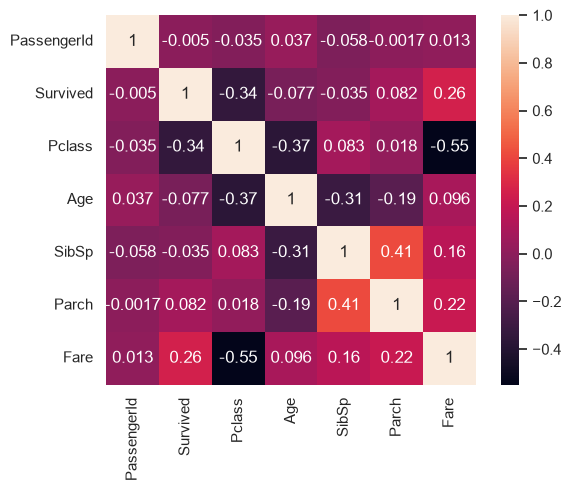

In [62]:
# Visualize feature correlations using a heatmap to identify patterns

sns.heatmap(corr_matrix, square=True, annot=True);

Main conclusions from the feature correlation matrix:

- **Relationship with the target variable (`Survived`)**  
  The most noticeable positive correlation with survival is shown by the `Fare` feature (0.26). This means that passengers with higher ticket fares more often had a higher chance of survival. However, this feature should not be considered in isolation, as ticket price is closely related to the passenger's social status and cabin class.

  The `Pclass` feature has a negative correlation with `Survived` (-0.34). Since class values increase from first to third class, the negative relationship indicates that lower-class passengers, on average, had a lower probability of survival.

- **Influence of age (`Age`)**  
  The correlation between age and survival is weak and negative (-0.077). This indicates that age itself is not a strong linear factor of survival. However, the direction of the relationship shows a slight tendency: among older passengers, the probability of survival was somewhat lower.

- **Relationship between class (`Pclass`) and ticket fare (`Fare`)**  
  A strong negative correlation is observed between `Pclass` and `Fare` (-0.55). This is an expected relationship: first-class passengers generally paid higher ticket fares, while third-class passengers had cheaper tickets. These features contain partially overlapping information about the passenger's social status, so possible multicollinearity should be considered during further modeling.

- **Family features (`SibSp` and `Parch`)**  
  A moderate positive relationship is observed between the number of relatives on board (`SibSp`, `Parch`) (0.41). Both features describe the size of the passenger's family group, so during Feature Engineering they can be considered for combining into a single feature, such as `FamilySize`.

- **Passenger identifier (`PassengerId`)**  
  This feature has almost no relationship with survival (-0.005), which confirms its technical nature. It represents only the record order number and does not contain information about the passenger, so it should not be used for model training.

Overall, the correlation analysis shows that the most informative numerical features for predicting survival are `Pclass` and `Fare`. However, it is important to consider that linear correlation does not capture all possible relationships between features and the target variable, so further analysis of categorical features and model training are necessary to obtain a more complete understanding of survival factors.

## 5 Feature Engineering and Data Preprocessing

### 5.1 Overview

In this section, we will prepare the data before training the model.

The main tasks of the preprocessing stage can be divided into the following steps:

- handling missing values;
- converting features into a format suitable for the model;
- creating new features based on existing data;
- removing features that do not contain useful information.

At this stage, it is important to remember the separation of data into training (`train`) and test (`test`) sets. All data preprocessing parameters must be calculated only on the training set to avoid data leakage.

### 5.2 Handling Missing Values

Before training the model, it is necessary to handle missing values. Different features require different approaches:

- `Age` - we will fill missing values with the median age within passenger groups with the same `Pclass` and `Sex`;
- `Fare` - we will fill missing values with the median ticket fare within the passenger class;
- `Cabin` - we will preserve the information about cabin availability and replace missing values with a separate category `U` (`Unknown`);
- `Embarked` - we will remove rows with missing values, as there are very few such cases.

The `Age` feature contains around 20% missing values, so removing these rows would lead to the loss of a significant amount of data. Additionally, passenger age has different distributions depending on passenger class and gender. Therefore, instead of using a general average value, we will use the median age within the `Pclass + Sex` groups.

In [63]:
# Calculate median age for each combination of passenger class and gender

age_medians = train.groupby(["Pclass", "Sex"])["Age"].median()


# Create group identifiers for train and test data

train_keys = list(zip(train["Pclass"], train["Sex"]))
test_keys = list(zip(test["Pclass"], test["Sex"]))


# Fill missing ages using the corresponding group median

train["Age"] = train["Age"].fillna(pd.Series(train_keys, index=train.index).map(age_medians))


test["Age"] = test["Age"].fillna(pd.Series(test_keys, index=test.index).map(age_medians))

The `Fare` feature contains only one missing value in the test dataset. Ticket price depends on the passenger class (`Pclass`), so instead of removing the row, we will replace the missing value with the median ticket fare for the corresponding class. As in the case of `Age`, the median value will be calculated based on the training dataset.

In [64]:
# Calculate median fare for each passenger class

fare_medians = train.groupby(["Pclass"])["Fare"].median()

In [65]:
# Fill missing fares using passenger class median

test["Fare"] = test["Fare"].fillna(test["Pclass"].map(fare_medians))

The `Cabin` feature contains 77% missing values. We will not remove this feature completely, as even incomplete cabin information may be useful.

The first letter of the cabin number indicates the deck (`Deck`), which may be related to the passenger's location on the ship. For missing values, we will create a separate category `U` (`Unknown`). This will allow us to preserve information about the absence of cabin data itself.

In [66]:
# Replace missing cabin values with "U" (Unknown)

train["Cabin"] = train["Cabin"].fillna("U")
test["Cabin"] = test["Cabin"].fillna("U")

The `Embarked` feature contains only two missing values in the training dataset. Since it is not possible to reliably recover the boarding port based on other features, we will remove these rows from the dataset. The loss of a few observations will not have a significant impact on the dataset size.

In [67]:
# Remove rows with missing embarkation port


train = train.dropna(subset=("Embarked"))

### 5.3 Feature Engineering and Feature Selection

For convenience, we will perform the same operations on both the training and test datasets simultaneously. We will create a list containing both dataframes, which will allow us to apply identical preprocessing steps to both datasets.

In [68]:
# Store train and test datasets together for applying the same transformations

combine = [train, test]

We will create a new feature `FamilySize` by combining the information from `SibSp` and `Parch`. Instead of using two separate features, we will use the total size of the passenger's family group: `FamilySize = SibSp + Parch + 1`.

This feature may better represent the passenger's family situation and simplify the process of finding patterns for the model.

In [69]:
# Create a feature representing the total family size

for df in combine:
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

To make it easier for the model to find patterns, we will transform the numerical family size into several categories.

We will create three groups:

- `Alone` - the passenger is traveling alone;
- `Small` - a small family;
- `Large` - a large family.

In [70]:
# Convert numerical family size into categorical groups:
# Alone, Small family, Large family

for df in combine:
    df["FamilyGroup"] = pd.cut(
        df["FamilySize"],
        bins=[0, 1, 3, float("inf")],
        labels=["Alone", "Small", "Large"]
    )

We will create a new categorical feature `Title` by extracting passenger titles from the original `Name` feature.

Since some titles appear only in a small number of observations, we will combine rare categories into a single group `Rare`. This transformation will be applied simultaneously to the training and test datasets to maintain the same structure of the `Title` feature and avoid the appearance of categories present in only one of the datasets.

As a result, the number of feature categories will be reduced, while information about the presence of an uncommon title will be preserved for further model training.

In [71]:
# Extract passenger titles from the Name column

for df in combine:
    df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.")[0]

# Merge equivalent title categories

title_mapping = {
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
}

for df in combine:
    df["Title"] = df["Title"].replace(title_mapping)

# Group uncommon titles into a single category

common_titles = {"Mr", "Mrs", "Miss", "Master"}

for df in combine:
    df["Title"] = df["Title"].where(
        df["Title"].isin(common_titles),
        "Rare"
    )

Previously, we identified the potential usefulness of information from the `Cabin` feature.

We will create two new features:

- `HasCabin` — indicates whether cabin information is available;
- `Deck` — the first letter of the cabin number, representing the deck.

Rare deck values will be combined into a separate category `Rare` to reduce the number of unique categories.

It is important to consider that the created features have a certain dependency. For example, the absence of cabin information (`HasCabin = 0`) corresponds to the category `Deck = U`. Therefore, these features partially duplicate each other. In this educational example, we will keep both features, as the dataset is small and logistic regression uses regularization, which helps reduce the impact of redundant features.

In [72]:
# Group rare deck values into a single category

rare_decks = {"A": "Rare", "F": "Rare", "G": "Rare", "T": "Rare"}

for df in combine:
     # Create a feature indicating whether cabin information exists
    
    df["HasCabin"] = (df["Cabin"] != "U").astype(int)

    # Extract deck from cabin number
    df["Deck"] = df["Cabin"].str[0]
    
    # Replace rare decks with a common category
    df["Deck"] = df["Deck"].replace(rare_decks)

The original `Ticket` feature contains a large number of unique values and is not suitable for direct use in the model, as we determined during the EDA stage. However, the ticket number contains additional information about passenger groups: several people could travel under the same ticket.

We will use this property to create new features:

- `TicketCount` — the number of passengers with the same ticket number;
- `FarePerPerson` — the ticket fare calculated per passenger.

In [73]:
# Count the number of passengers sharing the same ticket

all_tickets = pd.concat([df["Ticket"] for df in combine])
ticket_counts = all_tickets.value_counts()

for df in combine:
    # Create a feature representing ticket group size
    
    df["TicketCount"] = df["Ticket"].map(ticket_counts)

    # Calculate fare per passenger
    
    df["FarePerPerson"] = df["Fare"] / df["TicketCount"]


    # Apply logarithmic transformation to reduce the impact of extreme values
    # and make the FarePerPerson distribution less skewed
    
    df["FarePerPerson"] = np.log1p(df["FarePerPerson"])

In this educational example, the number of passengers with the same ticket is calculated using the combined `train` and `test` datasets, as this feature does not use information from the target variable.

Previously, while analyzing the distribution of the `Fare` feature, we observed a strong right skew with a long tail caused by passengers with high ticket fare values. Such a data structure can lead to excessive influence of extreme values during logistic regression training.

Since the `FarePerPerson` feature preserves a similar distribution characteristic, we will apply a logarithmic transformation using the `numpy.log1p()` function. This will reduce the influence of large feature values and make its distribution more suitable for model training.

After creating the new features, we will remove the original columns that are no longer needed for model training.

Some features have been replaced with more informative versions:

- `SibSp` and `Parch` → `FamilySize` and `FamilyGroup`;
- `Cabin` → `Deck` and `HasCabin`;
- `Ticket` → `TicketCount` and `FarePerPerson`.

We will also save `PassengerId` from the test dataset separately, as it will only be needed for creating the final prediction file.

In [74]:
# Save passenger IDs for final submission

test_id = test["PassengerId"]

In [75]:
# Remove unused and replaced features

train = train.drop(["PassengerId", "Name", "SibSp", "Parch", "Ticket", "Fare", "Cabin", "FamilySize", "TicketCount"], axis=1)
test = test.drop(["PassengerId", "Name", "SibSp", "Parch", "Ticket", "Fare", "Cabin", "FamilySize", "TicketCount"], axis=1)

Logistic regression works with a numerical feature matrix, so categorical features must be transformed into a numerical format.

We will use one-hot encoding to create binary features from categorical variables:

- `Sex`;
- `Embarked`;
- `FamilyGroup`;
- `Deck`.

The `drop_first=True` parameter removes one category from each group of binary features. This helps avoid perfect linear dependency between the created variables, which is especially important for linear models.

In [76]:
# Convert categorical features into numerical representation

train = pd.get_dummies(train, columns=["Sex", "Embarked", "FamilyGroup", "Deck", "Title"], drop_first=True)

test = pd.get_dummies(test, columns=["Sex", "Embarked", "FamilyGroup", "Deck", "Title"], drop_first=True)

Let's check the final dimensions of the datasets after all preprocessing steps and feature engineering.

In [77]:
# Check final dataset dimensions after preprocessing

train.shape

(889, 19)

In [78]:
# Check final dataset dimensions after preprocessing

test.shape

(418, 18)

## 6 Model Training and Evaluation

### 6.1 Introduction

At this stage, we will build a machine learning model to solve the binary classification problem. Using the results of the previous data analysis and feature preparation stages, we will train a logistic regression model and evaluate its performance using the main classification metrics.

The training process will include the following steps:

- splitting the data into training and validation sets;
- scaling numerical features;
- training the baseline Logistic Regression model;
- evaluating model performance;
- performing cross-validation and hyperparameter tuning using GridSearchCV.

All data preprocessing and model training steps will be combined into a single Pipeline, which will help prevent data leakage and provide a reproducible training process.

### 6.2 Logistic Regression Model Training

We will import the necessary tools from the `sklearn` library, which will be used to build the pipeline, train the model, perform cross-validation, tune hyperparameters, and evaluate classification performance.

In [79]:
# Import tools for building the machine learning pipeline

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Import tools for data splitting, cross-validation and hyperparameter tuning

from sklearn.model_selection import(
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

# Import evaluation metrics and visualization tools

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)

First, we will split the data into features and the target variable `Survived`.

The Kaggle test set will only be used to obtain final predictions, so all stages of training, validation, and hyperparameter tuning will be performed exclusively on the training data.

In [80]:
# Separate features and target variable

X = train.drop("Survived", axis=1)
y = train["Survived"]

We will split the original training dataset into two parts:

- **80% of the data** will be used for model training (`training set`);
- **20% of the data** will be used to evaluate model performance (`validation set`).

After the split, we will obtain:

- `X_train` and `y_train` - data used for model training;
- `X_val` and `y_val` - data used for independent model evaluation.

The `test_size=0.2` parameter means that 20% of the original data will be allocated to the validation set, while `stratify=y` preserves the original class distribution of the target variable in both datasets. This is especially important for classification tasks, as it ensures that the model is trained and evaluated on data with similar class proportions.

In [81]:
# Split data into training and validation sets

X_train, X_val, y_train, y_val = train_test_split(
    X, 
    y, 
    test_size=0.2,
    random_state=42
)

We will create a Pipeline that combines data preprocessing steps and model training.

Using a Pipeline helps prevent data leakage during feature scaling in cross-validation, as `StandardScaler` will be fitted only on the corresponding training part of each fold.

As the preprocessing step, we will apply feature standardization using `StandardScaler`. It transforms numerical features to a common scale: the mean value becomes close to 0, and the standard deviation becomes close to 1. This approach is especially important for Logistic Regression, as the model uses feature coefficients that can be affected by different scales of the original data.

In [82]:
# Create baseline pipeline with feature scaling and Logistic Regression model

baseline_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(max_iter=1000))
])

We will train the baseline Logistic Regression model without hyperparameter tuning. This result will be used as a baseline, allowing us to compare it with further improvements after applying cross-validation and optimizing model parameters.

In [83]:
# Train baseline model on the training data

baseline_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['Pclass','Age','HasCabin',...,'Title_Mr','Title_Mrs','Title_Rare']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


We will obtain predictions from the baseline model and evaluate its performance using classification metrics.

In [84]:
# Generate class predictions on the validation set

y_baseline_pred = baseline_pipeline.predict(X_val)

First, we will evaluate the model using the Confusion Matrix.

This matrix shows the number of correct and incorrect predictions for each class:

- **TP (True Positive)** - the model correctly predicted the positive class;
- **TN (True Negative)** - the model correctly predicted the negative class;
- **FP (False Positive)** - the model incorrectly predicted the positive class;
- **FN (False Negative)** - the model incorrectly predicted the negative class.

This analysis allows us to understand not only the overall model performance but also the nature of the errors made by the model.

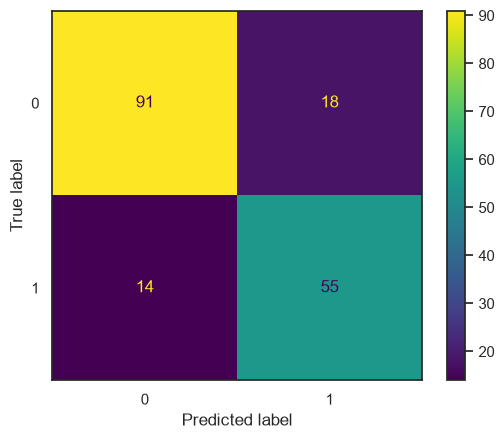

In [85]:
# Display confusion matrix for validation predictions

with sns.axes_style("white"):
    ConfusionMatrixDisplay.from_estimator(
        baseline_pipeline,
        X_val,
        y_val
    );

The model correctly identified:

- 91 passengers who did not survive (**True Negative**);
- 55 passengers who survived (**True Positive**).

The classification errors included:

- 18 **False Positive** cases - the model predicted survival, but the passenger did not survive;
- 14 **False Negative** cases - the model predicted death, but the passenger survived.

Thus, the model made 32 incorrect predictions out of 179 objects in the validation set.

For a baseline Logistic Regression model without hyperparameter optimization, this result is an acceptable starting point. Next, we will compare it with other evaluation metrics and check whether the model performance can be improved using cross-validation and parameter tuning.

The next metric we will consider is Accuracy. Accuracy represents the proportion of correct predictions among all observations and is calculated as follows:

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

In [86]:
# Calculate accuracy on the validation set

accuracy_score(y_val, y_baseline_pred)

0.8202247191011236

The obtained Accuracy value is approximately 82%, which means that the model correctly classified about 8 out of 10 objects in the validation dataset.

However, Accuracy is not always a sufficient metric for evaluating classifier performance, especially when there is a class imbalance. Therefore, we will additionally consider Precision, Recall, F1-score, and ROC-AUC.

**Precision** shows how often the model was correct among all objects it classified as the positive class. In other words: if the model predicts that a passenger survived, how likely is this prediction to be correct. A high Precision value means a smaller number of false positive predictions (**False Positive**).

It is calculated using the formula:

$$
Precision = \frac{TP}{TP + FP}
$$

**Recall** shows what proportion of positive class objects the model was able to identify among all truly positive objects. In other words: among all passengers who actually survived, how many were correctly detected by the model.

It is calculated using the formula:

$$
Recall = \frac{TP}{TP + FN}
$$

**F1-score** combines Precision and Recall into a single metric.

It is useful when both types of errors are important:

- the number of false positive predictions;
- the number of missed positive objects.

The higher the F1-score, the better the model maintains a balance between Precision and Recall.

It is calculated using the formula:

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

In [87]:
# Display classification metrics on the validation set

print(classification_report(y_val, y_baseline_pred))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85       109
           1       0.75      0.80      0.77        69

    accuracy                           0.82       178
   macro avg       0.81      0.82      0.81       178
weighted avg       0.82      0.82      0.82       178



For the survived class (`1`), the model showed the following results:

- **Precision = 0.75** - among all passengers predicted by the model as survivors, approximately 75% actually survived. The remaining predictions were false positives (**False Positive**).

- **Recall = 0.80** - the model was able to correctly identify around 78% of all passengers who actually survived. The remaining cases were missed by the model (**False Negative**).

- **F1-score = 0.77** - represents the balance between Precision and Recall and shows that the model has relatively stable performance when identifying surviving passengers.

When comparing the two classes, we can see that the model performs better at recognizing passengers who did not survive (`0`):

- F1-score for class 0 = 0.85;
- F1-score for class 1 = 0.77.

This happens because the model makes more errors when identifying survivors, which can be seen from the Precision and Recall values for the positive class.

Next, we will evaluate the model using the ROC curve (Receiver Operating Characteristic).

The ROC curve shows how the model's ability to separate two classes changes when the classification threshold is adjusted.

The Y-axis represents True Positive Rate (TPR), which shows the proportion of correctly identified positive class objects:

$$
TPR = \frac{TP}{TP + FN}
$$

The X-axis represents False Positive Rate (FPR), which shows the proportion of negative class objects incorrectly classified as positive:

$$
FPR = \frac{FP}{FP + TN}
$$

Each point on the ROC curve corresponds to a specific classification threshold. By changing this threshold, we can achieve different trade-offs between the number of correctly detected positive objects and the number of false positive predictions.

In [88]:
# Calculate ROC-AUC score using predicted probabilities

roc_auc_score(
    y_val,
    baseline_pipeline.predict_proba(X_val)[:, 1]
)

0.86158755484643

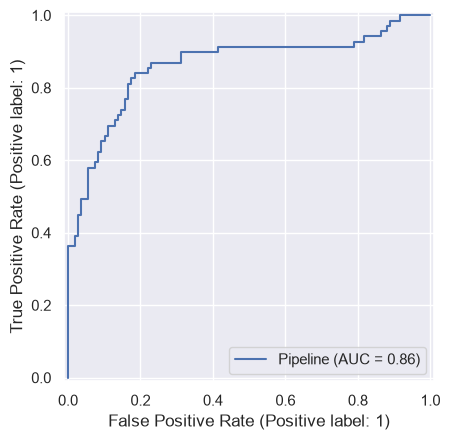

In [89]:
# Plot ROC curve for the baseline model

RocCurveDisplay.from_estimator(
    baseline_pipeline,
    X_val,
    y_val
);

The obtained ROC-AUC value is 0.86. ROC-AUC demonstrates the model's ability to separate the two classes regardless of the selected classification threshold.

The value interpretation:

- 0.5 corresponds to a model that performs no better than random guessing;
- 1.0 corresponds to perfect class separation.

The obtained value of 0.86 indicates that the baseline model is already able to distinguish survivors and non-survivors quite well, even without additional hyperparameter optimization. This provides a strong starting point for further model improvement.

The next step is to apply cross-validation for a more objective evaluation of the baseline model.

We will use `StratifiedKFold`, which will divide the training dataset into 5 parts (`folds`) while preserving the original class distribution in each fold. This is especially important for classification tasks, as each fold should contain a similar proportion of target classes.

In [90]:
# Create stratified cross-validation strategy

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

As the main metric for cross-validation, we will use ROC-AUC. For this task, it is more suitable than Accuracy alone, as it provides a more complete evaluation of the model's ability to rank prediction probabilities and distinguish between the two classes across different classification thresholds.

In [91]:
# Evaluate baseline model using stratified cross-validation

cv_scores = cross_val_score(
    baseline_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

We will examine the ROC-AUC score for each fold and calculate the average value to evaluate the baseline model stability.

In [92]:
# Display ROC-AUC score for each fold

cv_scores

array([0.86745868, 0.81912879, 0.90035774, 0.82954545, 0.90467172])

In [93]:
# Calculate average ROC-AUC score across all folds

cv_scores.mean()

np.float64(0.8642324762779307)

The cross-validation results show that the mean ROC-AUC score is approximately 0.864. This value is very close to the result obtained on the separate validation set, indicating that the baseline model provides stable performance.

The next step is to perform hyperparameter tuning for Logistic Regression using `GridSearchCV`.

We will define a parameter grid to search for the optimal combination of:

- regularization type (`penalty`);
- regularization strength (`C`);
- optimization algorithm (`solver`).

In this experiment, we will focus on L2 regularization, which is the standard choice for Logistic Regression and helps reduce the impact of excessively large model coefficients.

The optimization criterion will be ROC-AUC, as this metric was already used for baseline cross-validation and allows objective comparison of the results.

In [94]:
# Define hyperparameter grid for Logistic Regression optimization

param_grid = [
    {
        "logistic_regression__penalty": ["l2"],
        "logistic_regression__C": np.logspace(-4, 4, 9),
        "logistic_regression__solver": ["lbfgs", "saga"]
    }
]

The parameter `C` is the inverse of the regularization strength.

- A small value of `C` increases the regularization effect and more strongly limits the model coefficients.
- A large value of `C` reduces the influence of regularization, allowing the model to fit the training data more closely.

`GridSearchCV` will test different values of `C` and select the parameter combination with the highest mean ROC-AUC score during cross-validation.

In [95]:
# Initialize GridSearchCV for hyperparameter optimization

grid = GridSearchCV(
    baseline_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

In [96]:
# Train GridSearchCV to find the best Logistic Regression hyperparameters

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'logistic_regression__C': array([1.e-04... 1.e+04]), 'logistic_regression__penalty': ['l2'], 'logistic_regression__solver': ['lbfgs', 'saga']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionc

In [97]:
grid.best_params_

{'logistic_regression__C': np.float64(10.0),
 'logistic_regression__penalty': 'l2',
 'logistic_regression__solver': 'saga'}

`GridSearchCV` selected the following hyperparameter combination:

- **C = 10.0** - the inverse regularization strength parameter. A larger value of `C` means weaker regularization, allowing the model more freedom to adjust coefficients based on the training data. In this case, the search showed that stronger coefficient constraints did not improve model performance.

- **penalty = l2** - L2 regularization was selected. It limits the growth of model coefficients and helps reduce the risk of overfitting by applying a penalty to large weight values.

- **solver = saga** - the selected optimization algorithm supports L2 regularization and is suitable for training Logistic Regression on tabular datasets.

The selected hyperparameter combination was chosen based on the highest mean ROC-AUC score during cross-validation. Compared with the baseline model, the improvement in performance was not significant, indicating that increasing model complexity is not necessary at this stage.

The selected parameters will be used to train the final model on the complete training dataset.

In [98]:
# Display the best ROC-AUC score achieved during GridSearchCV

grid.best_score_

np.float64(0.8646541169268442)

The obtained results:

- Baseline ROC-AUC: 0.862
- Cross-validation ROC-AUC: 0.864
- Best GridSearchCV ROC-AUC: 0.864

After hyperparameter tuning, we observe a small improvement in the mean ROC-AUC compared with the baseline model.

However, the improvement is minor, so we will additionally check other evaluation metrics to determine whether the classification quality of individual classes has changed.

In [99]:
y_grid_pred = grid.predict(X_val)

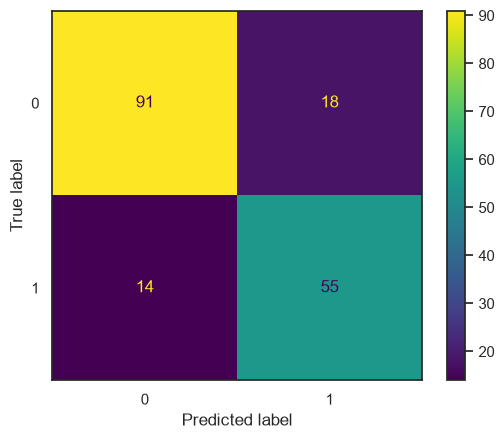

In [100]:
# Display confusion matrix for GridSearchCV model

with sns.axes_style("white"):
    ConfusionMatrixDisplay.from_estimator(
        grid,
        X_val,
        y_val
    );

In [101]:
# Calculate accuracy fro the optimized model

accuracy_score(y_val, y_grid_pred)

0.8202247191011236

In [102]:
print(classification_report(y_val, y_grid_pred))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85       109
           1       0.75      0.80      0.77        69

    accuracy                           0.82       178
   macro avg       0.81      0.82      0.81       178
weighted avg       0.82      0.82      0.82       178



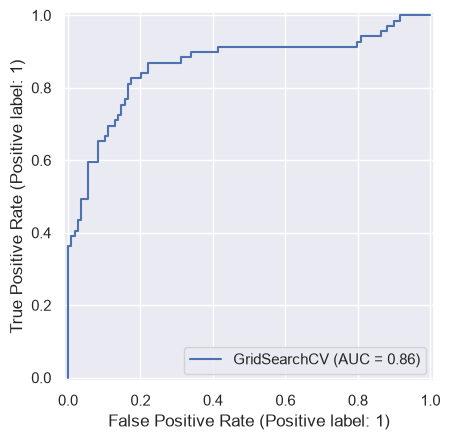

In [103]:
# Plot ROC curve for the optimized model

RocCurveDisplay.from_estimator(
    grid,
    X_val,
    y_val
);

After hyperparameter tuning using `GridSearchCV`, no significant improvement in model performance was achieved.

The main classification metrics remained almost identical to the baseline model:

- Accuracy remained unchanged;
- Precision, Recall, and F1-score for both classes also showed almost no difference;
- ROC-AUC increased from 0.862 to 0.864, which is a minor improvement.

The results indicate that the Logistic Regression architecture with the current feature set has already reached a stable performance level. Hyperparameter tuning helped identify a slightly more optimal regularization configuration, but it did not provide a meaningful increase in model quality.

It is important to note that the absence of significant improvement after `GridSearchCV` is not an error. Hyperparameter tuning does not always lead to higher metrics, especially when the baseline model already provides stable results.

At this stage, we can fix the selected hyperparameters and train the final model on the full available training dataset before generating the final predictions.

In [104]:
# Extract the best pipeline found by GridSearchCV

final_model = grid.best_estimator_

In [105]:
# Retrain the final model on the full labeled dataset

final_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['Pclass','Age','HasCabin',...,'Title_Mr','Title_Mrs','Title_Rare']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


Generate predictions for the test dataset and create the final `submission.csv` file with `PassengerId` and predicted `Survived` values.

In [106]:
# Generate predictions for the Kaggle test set

test_predictions = final_model.predict(test)

In [107]:
# Create Kaggle submission file

submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": test_predictions
})

submission.to_csv("submission.csv", index=False)

At the final stage, we will analyze the Logistic Regression coefficients to evaluate the influence of features on passenger survival and compare the results with the initial hypotheses from the EDA stage.

The coefficient sign indicates the direction of the feature influence:

- a positive coefficient increases the probability of survival;
- a negative coefficient decreases the probability of survival.

The absolute coefficient value (`Abs_Coefficient`) represents the strength of the feature influence in the model. The larger the value, the greater the contribution of the feature to the prediction.

In [108]:
# Extract and rank logistic regression coefficients to evaluate feature impact on survival prediction

logreg = final_model.named_steps["logistic_regression"]

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logreg.coef_[0]
})

coefficients["Abs_Coefficient"] = coefficients["Coefficient"].abs()

coefficients.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

,Feature,Coefficient,Abs_Coefficient
15,Title_Mr,-1.473614,1.473614
4,Sex_male,-1.449575,1.449575
14,Title_Miss,-1.279669,1.279669
16,Title_Mrs,-0.776185,0.776185
0,Pclass,-0.688282,0.688282
8,FamilyGroup_Large,-0.556516,0.556516
1,Age,-0.478510,0.478510
17,Title_Rare,-0.448594,0.448594
3,FarePerPerson,0.287124,0.287124
6,Embarked_S,-0.199929,0.199929


The model identified the following features as having the strongest influence:

- **Title_Mr (-1.474)** - one of the most significant factors with a negative impact. Passengers with this title had a substantially lower probability of survival. This supports the hypothesis that socio-demographic characteristics are important predictors.

- **Sex_male (-1.450)** - the strong negative coefficient indicates that male passengers had a significantly lower probability of survival. This result is consistent with the historical priority given to women and children during evacuation.

- **Title_Miss (-1.280)** and **Title_Mrs (-0.776)** - these titles also appeared as significant features, confirming the usefulness of extracting information from passenger names.

- **Pclass (-0.688)** - the negative influence of ticket class confirms the initial hypothesis: passengers from lower classes had lower chances of survival.

- **FamilyGroup_Large (-0.557)** - large family groups reduced the probability of survival. This may be related to the difficulties of evacuating a large number of people together.

- **Age (-0.479)** - age had a moderate negative influence: increasing age slightly reduced the probability of survival.

Less influential features:

- **Fare (+0.287)** showed a small positive effect. A higher ticket fare was associated with a higher probability of survival, indirectly reflecting differences in passenger social status.

- **Embarked_S (-0.200)** and other features with small coefficients had a limited impact on the model decision.

Overall, the coefficient analysis confirmed the main hypotheses from the study: the most important factors affecting survival were passenger gender, social status, ticket class, and age.

The obtained results will be summarized in the final feature importance table.

<table style="margin-left: 0; margin-right: auto; text-align: left; border-collapse: collapse; width: 100%;">
  <thead>
    <tr style="border-bottom: 2px solid #555;">
      <th style="text-align: left; padding: 8px;">Feature</th>
      <th style="text-align: left; padding: 8px;">Data Type</th>
      <th style="text-align: left; padding: 8px;">Expected Impact</th>
      <th style="text-align: left; padding: 8px;">Validation Result</th>
      <th style="text-align: left; padding: 8px;">Description</th>
    </tr>
  </thead>

  <tbody>
    <tr style="border-bottom: 1px solid #333;">
      <td style="padding: 8px;"><b>PassengerId</b></td>
      <td style="padding: 8px;">Numerical</td>
      <td style="padding: 8px;"><b>N/A</b></td>
      <td style="padding: 8px;"><b>Removed</b></td>
      <td style="padding: 8px;">Unique identifier without predictive value</td>
    </tr>
    <tr style="border-bottom: 1px solid #333;">
      <td style="padding: 8px;"><b>Survived</b></td>
      <td style="padding: 8px;">Binary</td>
      <td style="padding: 8px;"><b>Target</b></td>
      <td style="padding: 8px;"><b>Target variable</b></td>
      <td style="padding: 8px;">Target variable (0 = No, 1 = Yes)</td>
    </tr>
    <tr style="border-bottom: 1px solid #333;">
      <td style="padding: 8px;"><b>Pclass</b></td>
      <td style="padding: 8px;">Categorical</td>
      <td style="padding: 8px;"><b>High</b></td>
      <td style="padding: 8px;"><b>Confirmed: Negative (-0.688)</b></td>
      <td style="padding: 8px;">Lower passenger class reduced survival probability</td>
    </tr>
    <tr style="border-bottom: 1px solid #333;">
      <td style="padding: 8px;"><b>Name</b></td>
      <td style="padding: 8px;">String</td>
      <td style="padding: 8px;"><b>Medium</b></td>
      <td style="padding: 8px;"><b>Confirmed through feature engineering</b></td>
      <td style="padding: 8px;">Passenger name was transformed into title-based features</td>
    </tr>
    <tr style="border-bottom: 1px solid #333;">
      <td style="padding: 8px;"><b>Sex</b></td>
      <td style="padding: 8px;">Categorical</td>
      <td style="padding: 8px;"><b>High</b></td>
      <td style="padding: 8px;"><b>Confirmed: Strong negative effect for males (-1.450)</b></td>
      <td style="padding: 8px;">Male passengers had lower predicted survival probability</td>
    </tr>
    <tr style="border-bottom: 1px solid #333;">
      <td style="padding: 8px;"><b>Age</b></td>
      <td style="padding: 8px;">Numerical</td>
      <td style="padding: 8px;"><b>Medium</b></td>
      <td style="padding: 8px;"><b>Confirmed: Negative (-0.479)</b></td>
      <td style="padding: 8px;">Higher age slightly decreased survival probability</td>
    </tr>
    <tr style="border-bottom: 1px solid #333;">
      <td style="padding: 8px;"><b>SibSp</b></td>
      <td style="padding: 8px;">Numerical</td>
      <td style="padding: 8px;"><b>Low / Medium</b></td>
      <td style="padding: 8px;"><b>Replaced by family group features</b></td>
      <td style="padding: 8px;">Number of siblings/spouses aboard</td>
    </tr>
    <tr style="border-bottom: 1px solid #333;">
      <td style="padding: 8px;"><b>Parch</b></td>
      <td style="padding: 8px;">Numerical</td>
      <td style="padding: 8px;"><b>Low / Medium</b></td>
      <td style="padding: 8px;"><b>Replaced by family group features</b></td>
      <td style="padding: 8px;">Number of parents/children aboard</td>
    </tr>
    <tr style="border-bottom: 1px solid #333;">
      <td style="padding: 8px;"><b>Ticket</b></td>
      <td style="padding: 8px;">String</td>
      <td style="padding: 8px;"><b>Low</b></td>
      <td style="padding: 8px;"><b>Removed</b></td>
      <td style="padding: 8px;">High cardinality feature with limited direct predictive value</td>
    </tr>
    <tr style="border-bottom: 1px solid #333;">
      <td style="padding: 8px;"><b>Fare</b></td>
      <td style="padding: 8px;">Numerical</td>
      <td style="padding: 8px;"><b>Medium</b></td>
      <td style="padding: 8px;"><b>Confirmed: Positive (+0.287)</b></td>
      <td style="padding: 8px;">Higher fare slightly increased survival probability</td>
    </tr>
    <tr style="border-bottom: 1px solid #333;">
      <td style="padding: 8px;"><b>Cabin</b></td>
      <td style="padding: 8px;">String</td>
      <td style="padding: 8px;"><b>Medium</b></td>
      <td style="padding: 8px;"><b>Confirmed through deck features</b></td>
      <td style="padding: 8px;">Cabin information was transformed into deck-related features</td>
    </tr>
    <tr style="border-bottom: 1px solid #333;">
      <td style="padding: 8px;"><b>Embarked</b></td>
      <td style="padding: 8px;">String</td>
      <td style="padding: 8px;"><b>Low / Medium</b></td>
      <td style="padding: 8px;"><b>Weak impact (S: -0.200, Q: -0.054)</b></td>
      <td style="padding: 8px;">Port of embarkation had limited influence on prediction</td>
    </tr>
  </tbody>
</table>

## 7 Final Conclusion

This project demonstrates a complete workflow for solving a binary classification problem using the Titanic dataset, including exploratory data analysis, data preprocessing, feature engineering, model training, and performance evaluation.

During the analysis, key factors related to passenger survival were investigated, and additional features were created based on domain knowledge, including passenger titles, family size, cabin information, and ticket-based features.

The final model was built using Logistic Regression with preprocessing steps integrated into a single Pipeline to ensure a reproducible training process and prevent data leakage.

The results show that the model is able to capture the main survival patterns in the dataset. The most influential factors identified by the model were passenger gender, ticket class, age, and social-status-related features extracted from passenger information.

Further improvements could include testing additional machine learning algorithms, applying more advanced feature engineering techniques, and comparing different model architectures to improve predictive performance.

## Final Model Performance

- **Algorithm:** Logistic Regression
- **Validation Accuracy:** 0.816
- **Cross-validation ROC-AUC:** 0.864
- **Kaggle Submission Score:** 0.76

This project provides a practical example of applying machine learning methods to a real-world classification problem, from initial data exploration to final model evaluation.